# 1. Environment Setup & Data Loading

In [1]:
#  Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, f_oneway, zscore

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, 
                            roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi'        : 130,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FA',
    'axes.grid'         : True,
    'grid.alpha'        : 0.35,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'serif',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.titleweight'  : 'bold',
})

# Colour system
C = {
    'navy'   : '#0F2044', 'blue'  : '#1A56A0', 'teal'  : '#0D7A6A',
    'green'  : '#276749', 'amber' : '#B45309', 'red'   : '#991B1B',
    'slate'  : '#475569', 'gray'  : '#94A3B8',
}
DEPT_COLORS  = ['#1A56A0','#0D7A6A','#B45309','#991B1B','#5B21B6','#276749']
SRC_COLORS   = ['#1A56A0','#0D7A6A','#B45309','#991B1B']

print('Libraries loaded')
for lib, mod in [('pandas', pd), ('numpy', np), ('scipy', stats), ('seaborn', sns), ('sklearn','sklearn')]:
    try:
        v = mod.__version__
    except:
        import sklearn; v = sklearn.__version__
    print(f'   {lib}: {v}')

Libraries loaded
   pandas: 2.3.3
   numpy: 2.3.5
   scipy: 1.7.2
   seaborn: 0.13.2
   sklearn: 1.7.2


In [2]:
# Data Loading
DATA_PATH = 'recruitment_efficiency_improved.csv'

df_raw = pd.read_csv(DATA_PATH)
df     = df_raw.copy()

print(f'Dataset loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('── Schema')
print(df.dtypes)
print()
print('── First 5 rows')
df.head()

Dataset loaded: recruitment_efficiency_improved.csv
Shape: 5,000 rows × 8 columns

── Schema
recruitment_id             int64
department                object
job_title                 object
num_applicants             int64
time_to_hire_days          int64
cost_per_hire            float64
source                    object
offer_acceptance_rate    float64
dtype: object

── First 5 rows


,recruitment_id,department,job_title,num_applicants,time_to_hire_days,cost_per_hire,source,offer_acceptance_rate
0,1,Engineering,Software Engineer,280,24,1400.38,Referral,0.98
1,2,Sales,Account Executive,262,7,2730.45,LinkedIn,0.84
2,3,Product,UX Designer,11,76,5286.12,LinkedIn,0.83
3,4,Engineering,DevOps Engineer,238,26,5255.78,Recruiter,0.49
4,5,HR,Talent Acquisition,275,37,4987.03,LinkedIn,0.79


# 4. Feature Engineering & Selection Strategy

Approach: Because all numeric-vs-target correlations are near-zero and OAR is near-uniformly distributed.

## 4.1. Target Variable Engineering

Binary classification at the 70% threshold aligns with the KPI Depot benchmark for OAR, where ≥70% represents the minimum acceptable performance level (no immediate intervention required) and is used here as the boundary for 'high-performing hire.' This threshold reflects the industry standard at which recruitment outcomes are considered operationally stable.  
Business logic: A recruiter needs to know "Will this offer be accepted?" Not "What will the exact rate be?"

── Target Variable Summary
Binary (≥0.70):  1=2,175  (43.5%)  0=2,825  (56.5%)
Imbalance ratio  1.30:1 (Low:High)

Action: Use binary target (target_high_oar) as primary ML target.


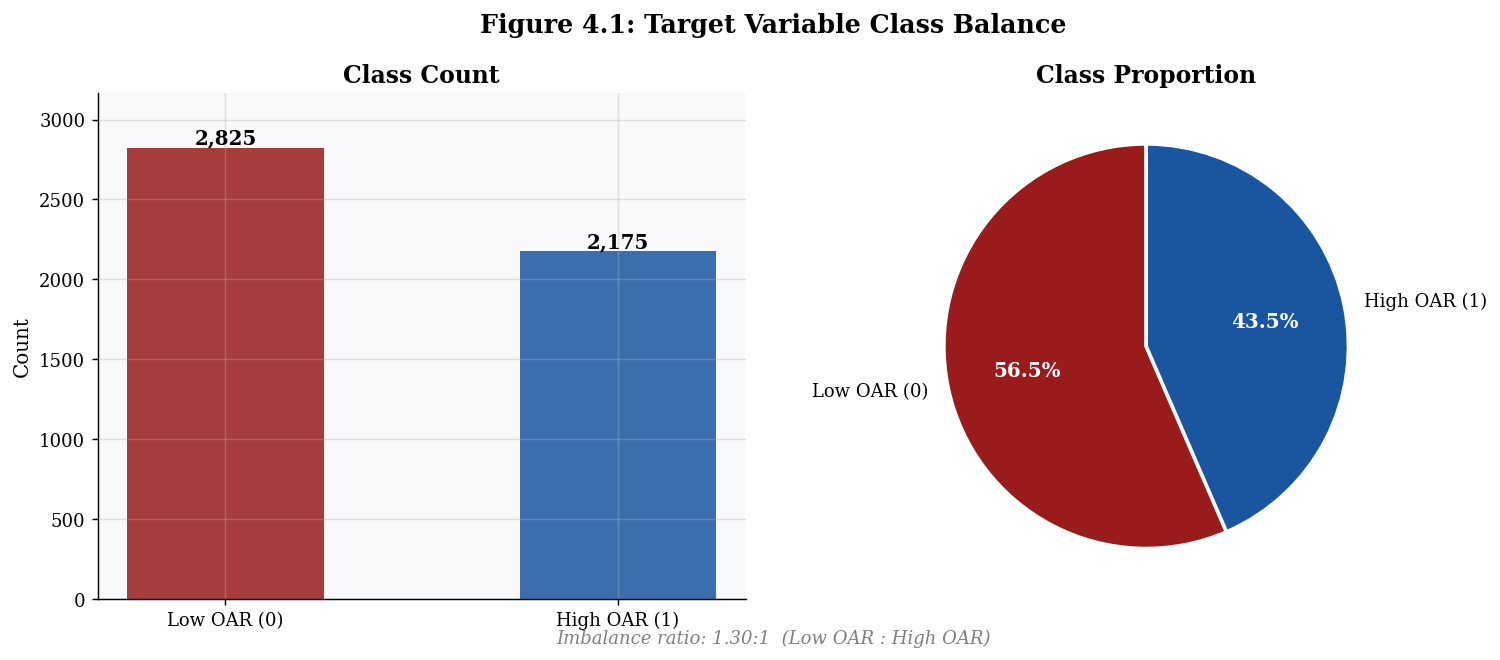

In [3]:
# Target Variable: Binary Classification
df_feat = df.copy()

# Primary binary target
df_feat['target_high_oar'] = (df_feat['offer_acceptance_rate'] >= 0.70).astype(int)

print('── Target Variable Summary')
print(f'Binary (≥0.70):  1={df_feat["target_high_oar"].sum():,}  ({100*df_feat["target_high_oar"].mean():.1f}%)  '
      f'0={len(df_feat)-df_feat["target_high_oar"].sum():,}  ({100*(1-df_feat["target_high_oar"].mean()):.1f}%)')
print(f'Imbalance ratio  {(1-df_feat["target_high_oar"].mean())/df_feat["target_high_oar"].mean():.2f}:1 (Low:High)')
print('\nAction: Use binary target (target_high_oar) as primary ML target.')

# Binary Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 4.1: Target Variable Class Balance',
             fontweight='bold', fontsize=14)

counts = df_feat['target_high_oar'].value_counts().sort_index()
labels = ['Low OAR (0)', 'High OAR (1)']
colors = [C['red'], C['blue']]

# Left: Bar chart
ax = axes[0]
bars = ax.bar(labels, counts.values, color=colors, alpha=0.85, width=0.5)
ax.set_title('Class Count')
ax.set_ylabel('Count')
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 20,
            f'{int(b.get_height()):,}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.12)

# Right: Pie chart
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts.values, labels=labels,
    autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11); t.set_fontweight('bold'); t.set_color('white')
ax.set_title('Class Proportion')

# Imbalance annotation
ratio = counts[0] / counts[1]
fig.text(0.5, 0.01, f'Imbalance ratio: {ratio:.2f}:1  (Low OAR : High OAR)',
         ha='center', fontsize=10, style='italic', color='grey')

plt.tight_layout()
plt.savefig('fig_4.1_target_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.2. New Feature Engineering

Raw features alone show near-zero signal. Derived features capture business-domain knowledge and potential non-linear interactions.

In [4]:
# Efficiency Ratios
# Logic: High spend with few applicants signals poor sourcing reach. Candidates sense a disorganized or desperate hiring process, 
#        which erodes confidence and lowers their willingness to accept an offer.
df_feat['cost_per_applicant'] = df_feat['cost_per_hire'] / df_feat['num_applicants']
# Logic: Captures daily resource burn rate. A fast but expensive hire suggests over-reliance on external recruiters; 
#        a slow but cheap one implies passive sourcing. Both extremes may indicate a poorly structured process that affects candidate experience.
df_feat['cost_per_day'] = df_feat['cost_per_hire'] / df_feat['time_to_hire_days']
# Logic: Pipeline velocity. Very low velocity signals an unattractive role or poorly written JD. 
#        Very high velocity means bulk low-intent applications flood the pipeline. Both extremes dilute match quality and reduce OAR.
df_feat['applicants_per_day'] = df_feat['num_applicants'] / df_feat['time_to_hire_days']

# Role context
# Logic: Senior candidates typically receive multiple competing offers and engage in harder salary negotiations. 
#        The longer decision cycle and higher market demand for their skills structurally depress offer acceptance rates for these roles.
df_feat['is_senior_role'] = (
    df['job_title']
    .str.contains(r'\b(manager|specialist|executive|strategist)\b', case=False, na=False)
    .astype(int)
)

# Auxiliary column for the dept+source combination encoding target
df_feat['dept_src_key'] = (
    df_feat['department'].astype(str) + '_' + df_feat['source'].astype(str)
)

In [5]:
X = df_feat.drop(columns=['target_high_oar']).copy()
y = df_feat['target_high_oar'].copy()
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)
 
print(f"── Train-Test Split:")
print(f"Train : {X_train.shape[0]:,} rows   |  High OAR: {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:,}  rows  |  High OAR: {y_test.mean()*100:.1f}%")

# Difficulty Additive
# Logic: Combines normalized time and cost into a single difficulty score.
#        Higher score = harder recruitment process, which may reduce candidate enthusiasm and OAR.
time_mean_train = X_train['time_to_hire_days'].mean()
time_std_train  = X_train['time_to_hire_days'].std()
cost_mean_train = X_train['cost_per_hire'].mean()
cost_std_train  = X_train['cost_per_hire'].std()
 
X_train['difficulty_additive'] = (
    (X_train['time_to_hire_days'] - time_mean_train) / time_std_train +
    (X_train['cost_per_hire']     - cost_mean_train) / cost_std_train
) / 2
 
X_test['difficulty_additive'] = (
    (X_test['time_to_hire_days'] - time_mean_train) / time_std_train +
    (X_test['cost_per_hire']     - cost_mean_train) / cost_std_train
) / 2

# Logic: DREI = 1 when a record simultaneously beats its department median on all three KPIs (lower cost, faster hire, higher OAR).
#        This creates a binary flag that captures "outlier efficiency" relative to the candidate's own department context — signal that global features
#        cannot encode because they are insensitive to departmental baselines.
# Compute department medians from TRAIN ONLY
dept_medians = (
    X_train
    .assign(offer_acceptance_rate=df_feat.loc[y_train.index, 'offer_acceptance_rate'].values)
    .groupby('department')
    .agg({
        'cost_per_hire'        : 'median',
        'time_to_hire_days'    : 'median',
        'offer_acceptance_rate': 'median'
    })
    .rename(columns={
        'cost_per_hire'        : 'dept_median_cph',
        'time_to_hire_days'    : 'dept_median_tth',
        'offer_acceptance_rate': 'dept_median_oar'
    })
)

# Join medians into train
X_train = X_train.join(dept_medians, on='department')

# Add OAR back temporarily for comparison
X_train['offer_acceptance_rate_temp'] = (
    df_feat.loc[y_train.index, 'offer_acceptance_rate'].values
)

# Create DREI (train)
X_train['drei'] = (
    (X_train['cost_per_hire'] < X_train['dept_median_cph']) &
    (X_train['time_to_hire_days'] < X_train['dept_median_tth']) &
    (X_train['offer_acceptance_rate_temp'] > X_train['dept_median_oar'])
).astype(int)

# Apply SAME medians to TEST
X_test = X_test.join(dept_medians, on='department')

X_test['offer_acceptance_rate_temp'] = (
    df_feat.loc[y_test.index, 'offer_acceptance_rate'].values
)

# Create DREI (test)
X_test['drei'] = (
    (X_test['cost_per_hire'] < X_test['dept_median_cph']) &
    (X_test['time_to_hire_days'] < X_test['dept_median_tth']) &
    (X_test['offer_acceptance_rate_temp'] > X_test['dept_median_oar'])
).astype(int)

# Cleanup temporary/helper columns
drop_cols = [
    'dept_median_cph',
    'dept_median_tth',
    'dept_median_oar',
    'offer_acceptance_rate_temp'
]

X_train.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)

print("\n── DREI Feature Created Successfully")
print(f"Train DREI positive rate : {X_train['drei'].mean()*100:.2f}%")
print(f"Test  DREI positive rate : {X_test['drei'].mean()*100:.2f}%")

# Target Encoding
# Logic: Group-level historical OAR as a proxy signal.
#        Fitted ONLY on y_train — X_test receives transform only.
GLOBAL_MEAN = y_train.mean()
SMOOTH_K    = 20
 
def fit_target_encoder(X_train, y_train, col, k=SMOOTH_K, global_mean=None):
    """
    Compute smoothed target encoding from the training set.
    encode(g) = (n_g * mean_g + k * global_mean) / (n_g + k)
    """
    if global_mean is None:
        global_mean = y_train.mean()
    temp = pd.DataFrame({'group': X_train[col].values, 'target': y_train.values})
    agg  = temp.groupby('group')['target'].agg(['mean', 'count'])
    mapping = ((agg['count'] * agg['mean'] + k * global_mean) / (agg['count'] + k)).to_dict()
    return mapping
 
def apply_target_encoder(X, col, mapping, global_mean=GLOBAL_MEAN):
    """
    Apply mapping to X[col].
    Unknown (unseen) categories → fall back to global_mean.
    """
    return X[col].map(mapping).fillna(global_mean)
 
# Fit from train
dept_map     = fit_target_encoder(X_train, y_train, 'department')
jobtitle_map = fit_target_encoder(X_train, y_train, 'job_title')
source_map   = fit_target_encoder(X_train, y_train, 'source')
deptsrc_map  = fit_target_encoder(X_train, y_train, 'dept_src_key')
 
# Apply to train
X_train['dept_oar_mean']        = apply_target_encoder(X_train, 'department',   dept_map)
X_train['jobtitle_oar_mean']    = apply_target_encoder(X_train, 'job_title',    jobtitle_map)
X_train['source_oar_mean']      = apply_target_encoder(X_train, 'source',       source_map)
X_train['dept_source_oar_mean'] = apply_target_encoder(X_train, 'dept_src_key', deptsrc_map)
 
# Apply to test (same mapping, y_test never touched)
X_test['dept_oar_mean']         = apply_target_encoder(X_test, 'department',   dept_map)
X_test['jobtitle_oar_mean']     = apply_target_encoder(X_test, 'job_title',    jobtitle_map)
X_test['source_oar_mean']       = apply_target_encoder(X_test, 'source',       source_map)
X_test['dept_source_oar_mean']  = apply_target_encoder(X_test, 'dept_src_key', deptsrc_map)
 
print(f"\n── Target Encoding — Global mean (train): {GLOBAL_MEAN:.4f}  |  K: {SMOOTH_K}")
print(f"Mapping department:")
for k, v in sorted(dept_map.items()):
    print(f"  {k:<15} → {v:.4f}")
print(f"\nMapping source:")
for k, v in sorted(source_map.items()):
    print(f"  {k:<15} → {v:.4f}")
print(f"\nMapping job_title:")
for k, v in sorted(jobtitle_map.items()):
    print(f"  {k:<35} → {v:.4f}")

print(f"\n── Anti-Leakage Validation:")
 
dept_map_test = fit_target_encoder(X_test, y_test, 'department')
print(f"Department encoding difference (train vs test) — delta must exist:")
for dept in dept_map:
    if dept in dept_map_test:
        delta = abs(dept_map[dept] - dept_map_test[dept])
        flag  = '✅ Different (safe)' if delta > 1e-6 else '❌ Identical!'
        print(f"  {dept:<15} train={dept_map[dept]:.4f}  test={dept_map_test[dept]:.4f}  |Δ|={delta:.6f}  {flag}")
 
corr_check = X_test['dept_oar_mean'].corr(y_test.reset_index(drop=True))
print(f"\nCorrelation of dept_oar_mean (test set) vs y_test : {corr_check:.4f}")
print(f"{'✅ Reasonable — no leakage detected' if abs(corr_check) < 0.9 else '❌ Too high!'}")
 
print(f"\nPipeline confirmation:")
print(f"- Ratio features created before split (target not touched)")
print(f"- difficulty_additive: mean & std fitted from X_train only")
print(f"- Target encoding fitted on y_train only")
print(f"- X_test receives transform only, y_test is not used")

FINAL_FEATURES = [
    'cost_per_applicant',
    'cost_per_day',
    'applicants_per_day',
    'is_senior_role',
    'difficulty_additive',
    'drei',
    'dept_oar_mean',
    'jobtitle_oar_mean',
    'source_oar_mean',
    'dept_source_oar_mean',
]
 
X_train_final = X_train[FINAL_FEATURES].copy()
X_test_final  = X_test[FINAL_FEATURES].copy()
 
# Evaluate correlations from TRAIN only
train_eval = X_train_final.copy()
train_eval['offer_acceptance_rate'] = df_feat.loc[y_train.index, 'offer_acceptance_rate'].values
train_eval['target_high_oar']       = y_train.values
 
corr_oar    = train_eval[FINAL_FEATURES + ['offer_acceptance_rate']].corr()['offer_acceptance_rate'].drop('offer_acceptance_rate')
corr_target = train_eval[FINAL_FEATURES + ['target_high_oar']].corr()['target_high_oar'].drop('target_high_oar')
corr_summary = pd.DataFrame({
    'Corr vs OAR (continuous)' : corr_oar,
    'Corr vs Target (binary)'  : corr_target,
    '|r|'                      : corr_oar.abs(),
}).sort_values('|r|', ascending=False)
 
print(f"\n── Correlation Evaluation (from Training Set):")
print(f"{'Feature':<28} {'r vs OAR':>10} {'r vs Target':>13} {'|r|':>8}")
print(f"{'-'*62}")
for feat, row in corr_summary.iterrows():
    print(f"{feat:<28} {row['Corr vs OAR (continuous)']:>10.4f} "
          f"{row['Corr vs Target (binary)']:>13.4f} {row['|r|']:>8.4f}")

── Train-Test Split:
Train : 4,000 rows   |  High OAR: 43.5%
Test  : 1,000  rows  |  High OAR: 43.5%

── DREI Feature Created Successfully
Train DREI positive rate : 12.47%
Test  DREI positive rate : 13.50%

── Target Encoding — Global mean (train): 0.4350  |  K: 20
Mapping department:
  Engineering     → 0.4412
  Finance         → 0.4203
  HR              → 0.4282
  Marketing       → 0.4772
  Product         → 0.4251
  Sales           → 0.4196

Mapping source:
  Job Portal      → 0.4394
  LinkedIn        → 0.4223
  Recruiter       → 0.4546
  Referral        → 0.4250

Mapping job_title:
  Account Executive                   → 0.4452
  Accountant                          → 0.4124
  Backend Developer                   → 0.4327
  Business Development Manager        → 0.3754
  Content Strategist                  → 0.4982
  Data Engineer                       → 0.4721
  DevOps Engineer                     → 0.4048
  Finance Manager                     → 0.4107
  Financial Analyst           

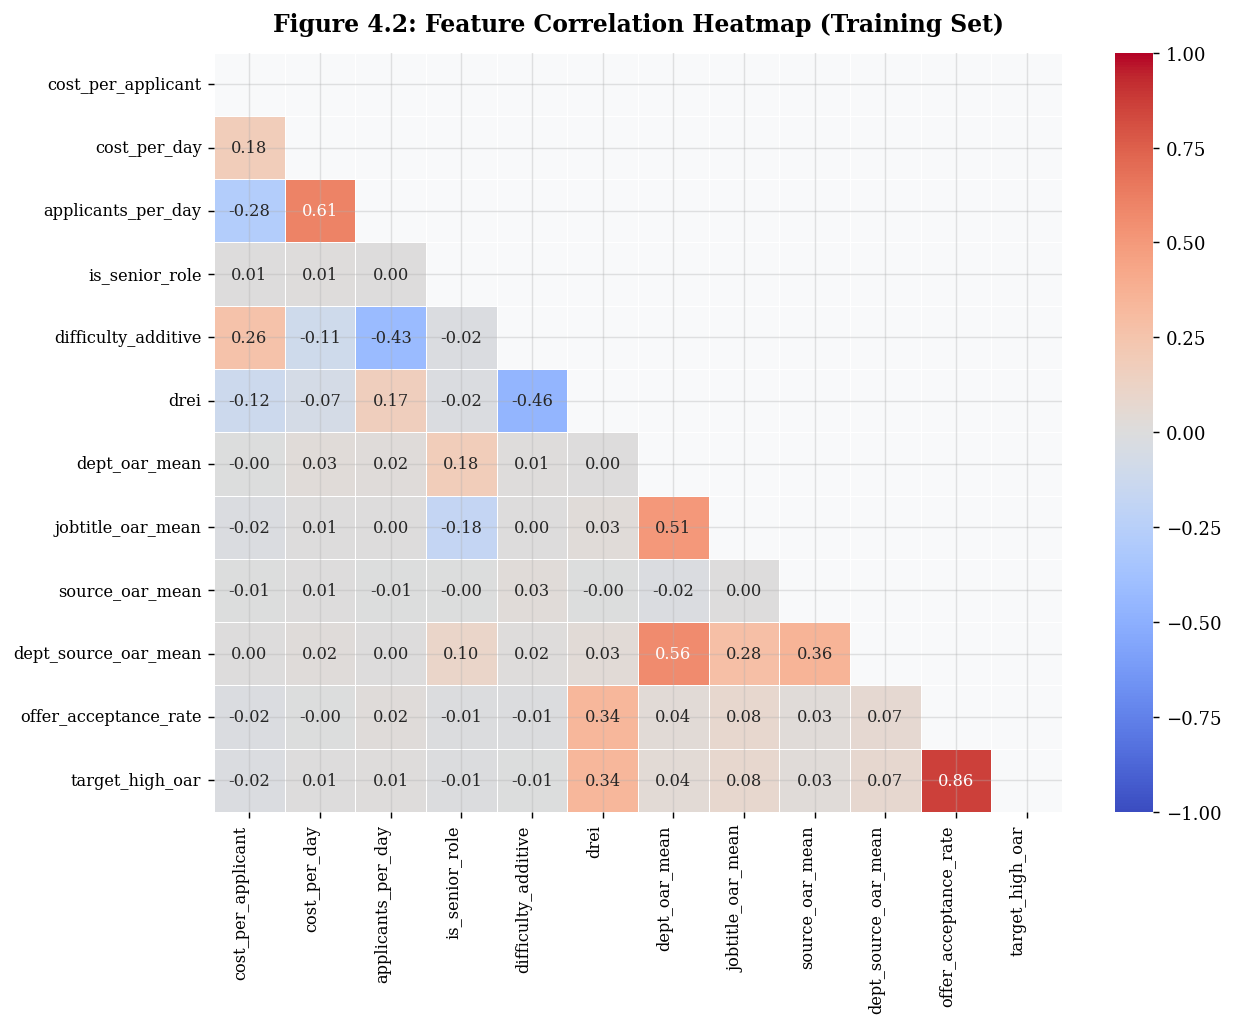

In [6]:
corr_matrix = X_train_final.copy()
corr_matrix['offer_acceptance_rate'] = df_feat.loc[y_train.index, 'offer_acceptance_rate'].values
corr_matrix['target_high_oar'] = y_train.values

corr_df = corr_matrix[FINAL_FEATURES + ['offer_acceptance_rate'] + ['target_high_oar']].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Figure 4.2: Feature Correlation Heatmap (Training Set)", fontsize=13, pad=12)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("fig_4.2_heatmap_features.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Rename to be consistent 
X_tr = X_train_final.copy()
X_te = X_test_final.copy()

# Check missing & infinite values
X_tr.replace([np.inf, -np.inf], np.nan, inplace=True)
X_te.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in X_tr.columns:
    med = X_tr[col].median()
    X_tr[col].fillna(med, inplace=True)
    X_te[col].fillna(med, inplace=True)
print(f"Missing  — train: {X_tr.isnull().sum().sum()}  test: {X_te.isnull().sum().sum()}")
print(f"Infinite — train: {np.isinf(X_tr.values).sum()}  test: {np.isinf(X_te.values).sum()}")

FEATURES_TO_SCALE = [f for f in X_tr.columns if f not in ('is_senior_role', 'drei')]
FEATURES_NO_SCALE = ['is_senior_role', 'drei']

# StandardScaler only on continuous numeric features
std_scaler = StandardScaler()

# Fit on train, transform both
X_train_scaled_part = pd.DataFrame(
    std_scaler.fit_transform(X_tr[FEATURES_TO_SCALE]),
    columns=FEATURES_TO_SCALE, index=X_tr.index
)
X_test_scaled_part = pd.DataFrame(
    std_scaler.transform(X_te[FEATURES_TO_SCALE]),
    columns=FEATURES_TO_SCALE, index=X_te.index
)

# Merge back with is_senior_role which is not scaled
X_train_std = pd.concat([X_train_scaled_part, X_tr[FEATURES_NO_SCALE]], axis=1)
X_test_std  = pd.concat([X_test_scaled_part,  X_te[FEATURES_NO_SCALE]], axis=1)

# Reorder columns to match original order
X_train_std = X_train_std[X_tr.columns]
X_test_std  = X_test_std[X_te.columns]

# No scaling → Decision Tree, Random Forest, XGBoost
X_train_raw = X_tr.copy()
X_test_raw  = X_te.copy()

# Save outputs
for X_train_out, X_test_out, suffix in [
    (X_train_std, X_test_std, 'standard_scaled'),
    (X_train_raw, X_test_raw, 'raw'),
]:
    tr = X_train_out.copy(); tr['target_high_oar'] = y_train.values
    te = X_test_out.copy();  te['target_high_oar'] = y_test.values
    tr.to_csv(f'train_{suffix}.csv', index=False)
    te.to_csv(f'test_{suffix}.csv',  index=False)
    print(f"Saved: train_{suffix}.csv & test_{suffix}.csv")

Missing  — train: 0  test: 0
Infinite — train: 0  test: 0
Saved: train_standard_scaled.csv & test_standard_scaled.csv
Saved: train_raw.csv & test_raw.csv


## 4.3. Class Imbalance Handling — SMOTE

**Problem:** The binary target has a 1.30:1 class imbalance (56.5% Low OAR vs 43.5%
High OAR). While this is mild compared to typical fraud or medical datasets, it still
causes classifiers to prefer the majority class, suppressing recall for the minority
(High OAR) class that is the primary business objective.

**Solution — SMOTE (Synthetic Minority Over-sampling Technique):**
- Generates synthetic minority-class samples by interpolating between existing minority
  neighbours in feature space
- Applied **only to the training set** — the test set is never touched (no leakage)
- Evaluated against: (a) no resampling, (b) `class_weight='balanced'`

**Why SMOTE over `class_weight`?**
- `class_weight` re-weights loss but does not add new information
- SMOTE creates new training examples that help decision boundaries in sparse minority
  regions of feature space
- Particularly beneficial for tree-based models where leaf purity is sensitive to sample counts

── SMOTE Results (raw feature space)
Before : Counter({0: 2260, 1: 1740})
After  : Counter({0: 2260, 1: 2260})
Rows added : 520
New balance: 50.0% High OAR  /  50.0% Low OAR

Scaled version — rows after SMOTE: 4,520

Saved: train_smote_raw.csv & train_smote_standard_scaled.csv
Note : X_test_raw and X_test_std are unchanged — SMOTE is train-only.


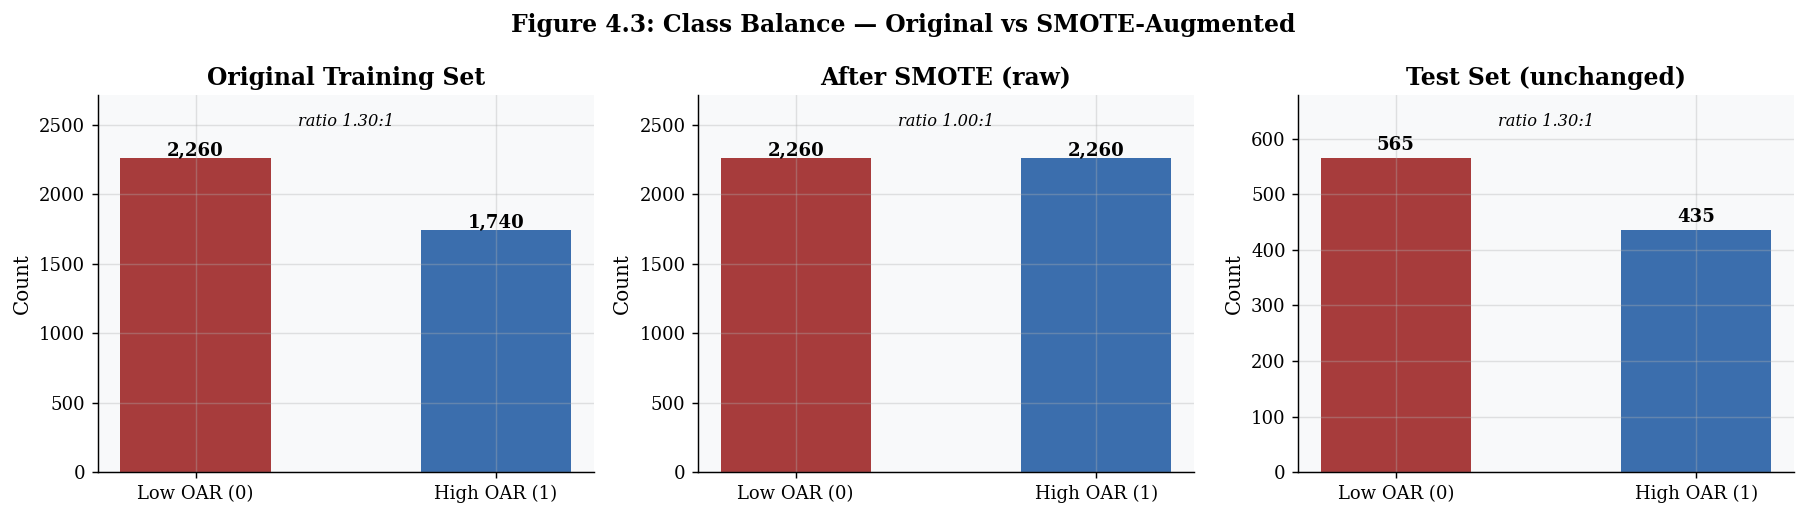

In [8]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# ── Apply SMOTE to the raw (unscaled) training set
# SMOTE is applied before scaling because it operates in the original feature space. 
# Scaling is then applied to the SMOTE-augmented set.
# NOTE: SMOTE is applied ONLY to X_train_raw — X_test_raw is never modified.

sm = SMOTE(random_state=42, k_neighbors=5)

X_train_smote_raw, y_train_smote = sm.fit_resample(X_train_raw, y_train)
X_train_smote_raw = pd.DataFrame(X_train_smote_raw, columns=X_train_raw.columns)
y_train_smote     = pd.Series(y_train_smote, name='target_high_oar')

print("── SMOTE Results (raw feature space)")
print(f"Before : {Counter(y_train)}")
print(f"After  : {Counter(y_train_smote)}")
print(f"Rows added : {len(y_train_smote) - len(y_train):,}")
print(f"New balance: {y_train_smote.mean()*100:.1f}% High OAR  /  {(1-y_train_smote.mean())*100:.1f}% Low OAR")

# ── Also apply SMOTE to the scaled training set
sm2 = SMOTE(random_state=42, k_neighbors=5)
X_train_smote_std, y_train_smote_std = sm2.fit_resample(X_train_std, y_train)
X_train_smote_std = pd.DataFrame(X_train_smote_std, columns=X_train_std.columns)
y_train_smote_std = pd.Series(y_train_smote_std, name='target_high_oar')

print(f"\nScaled version — rows after SMOTE: {len(X_train_smote_std):,}")

# ── Save SMOTE-augmented datasets
tr_smote_raw = X_train_smote_raw.copy()
tr_smote_raw['target_high_oar'] = y_train_smote.values
tr_smote_raw.to_csv('train_smote_raw.csv', index=False)

tr_smote_std = X_train_smote_std.copy()
tr_smote_std['target_high_oar'] = y_train_smote_std.values
tr_smote_std.to_csv('train_smote_standard_scaled.csv', index=False)

print("\nSaved: train_smote_raw.csv & train_smote_standard_scaled.csv")
print("Note : X_test_raw and X_test_std are unchanged — SMOTE is train-only.")

# ── Visualise class balance before/after
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figure 4.3: Class Balance — Original vs SMOTE-Augmented',
             fontweight='bold', fontsize=13)

for ax, (y_, title_) in zip(axes, [
    (y_train,       'Original Training Set'),
    (y_train_smote, 'After SMOTE (raw)'),
    (y_test,        'Test Set (unchanged)'),
]):
    cnts  = y_.value_counts().sort_index()
    clrs  = [C['red'], C['blue']]
    bars  = ax.bar(['Low OAR (0)','High OAR (1)'], cnts.values,
                   color=clrs, alpha=0.85, width=0.5)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+15,
                f'{int(b.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title_); ax.set_ylabel('Count')
    ax.set_ylim(0, cnts.max()*1.2)
    ratio = cnts.get(0, 0) / max(cnts.get(1, 1), 1)
    ax.text(0.5, 0.92, f'ratio {ratio:.2f}:1',
            ha='center', transform=ax.transAxes, fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('fig_4.3_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Model Development

## 5.1. Data Loading & Validation

In [9]:
# ── Load Stage-1 outputs
TARGET = 'target_high_oar'

# Original (no SMOTE) — used for baselines and GridSearch baseline comparisons
train_raw    = pd.read_csv('train_raw.csv')
test_raw     = pd.read_csv('test_raw.csv')
train_scaled = pd.read_csv('train_standard_scaled.csv')
test_scaled  = pd.read_csv('test_standard_scaled.csv')

X_train_raw    = train_raw.drop(columns=TARGET)
X_test_raw     = test_raw.drop(columns=TARGET)
X_train_scaled = train_scaled.drop(columns=TARGET)
X_test_scaled  = test_scaled.drop(columns=TARGET)
y_train        = train_raw[TARGET]
y_test         = test_raw[TARGET]

# SMOTE-augmented — used for RandomizedSearchCV and SMOTE-aware models
train_smote_raw = pd.read_csv('train_smote_raw.csv')
train_smote_std = pd.read_csv('train_smote_standard_scaled.csv')

X_train_smote_raw = train_smote_raw.drop(columns=TARGET)
X_train_smote_std = train_smote_std.drop(columns=TARGET)
y_train_smote     = train_smote_raw[TARGET]

FEATURE_NAMES = list(X_train_raw.columns)
FRIENDLY_NAMES = [
    'Cost / Applicant', 'Cost / Day', 'Applicants / Day',
    'Is Senior Role', 'Difficulty (Additive)',
    'Dept Efficiency', 'Job Title OAR Mean',
    'Source OAR Mean', 'Dept × Source OAR Mean', 'Dept OAR Mean'
]

print(f'Train (original)  : {X_train_raw.shape[0]:,} rows × {X_train_raw.shape[1]} features')
print(f'Train (SMOTE)     : {X_train_smote_raw.shape[0]:,} rows × {X_train_smote_raw.shape[1]} features')
print(f'Test              : {X_test_raw.shape[0]:,} rows × {X_test_raw.shape[1]} features')
print()
print('Feature list:')
for i, (f, fr) in enumerate(zip(FEATURE_NAMES, FRIENDLY_NAMES), 1):
    print(f'{i:2}. {f:<35} → {fr}')
print()
print('Sanity checks:')
print(f'NaN in X_train       : {X_train_raw.isna().sum().sum()}')
print(f'NaN in X_train_smote : {X_train_smote_raw.isna().sum().sum()}')
print(f'NaN in X_test        : {X_test_raw.isna().sum().sum()}')

Train (original)  : 4,000 rows × 10 features
Train (SMOTE)     : 4,520 rows × 10 features
Test              : 1,000 rows × 10 features

Feature list:
 1. cost_per_applicant                  → Cost / Applicant
 2. cost_per_day                        → Cost / Day
 3. applicants_per_day                  → Applicants / Day
 4. is_senior_role                      → Is Senior Role
 5. difficulty_additive                 → Difficulty (Additive)
 6. drei                                → Dept Efficiency
 7. dept_oar_mean                       → Job Title OAR Mean
 8. jobtitle_oar_mean                   → Source OAR Mean
 9. source_oar_mean                     → Dept × Source OAR Mean
10. dept_source_oar_mean                → Dept OAR Mean

Sanity checks:
NaN in X_train       : 0
NaN in X_train_smote : 0
NaN in X_test        : 0


## 5.2. Baseline Model — Logistic Regression

**Purpose:** Establish a performance benchmark. Every subsequent model must outperform this baseline to justify its additional complexity.  
**Why Logistic Regression as baseline?**
- Interpretable coefficients allow direct understanding of feature influence
- Fast to train; computationally cheap
- Assumes linear decision boundary — sets a lower bound; any model that cannot beat this is not useful
- Well-calibrated probabilities out of the box

In [10]:
# Baseline: Logistic Regression (default, no tuning)
baseline = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
baseline.fit(X_train_smote_std, y_train_smote)

y_pred_bl   = baseline.predict(X_test_scaled)
y_prob_bl   = baseline.predict_proba(X_test_scaled)[:, 1]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_bl       = cross_validate(baseline, X_train_smote_std, y_train_smote, cv=cv_strategy,
                             scoring=['accuracy','f1','roc_auc','precision','recall'], n_jobs=-1)

print("Baseline — Logistic Regression")
print(f"\nTest Set Performance:")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_bl):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_bl):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_bl):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred_bl):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_prob_bl):.4f}")
print(f"\n5-Fold Cross-Validation (train set):")
print(f"CV Accuracy : {cv_bl['test_accuracy'].mean():.4f} ± {cv_bl['test_accuracy'].std():.4f}")
print(f"CV F1       : {cv_bl['test_f1'].mean():.4f} ± {cv_bl['test_f1'].std():.4f}")
print(f"CV AUC-ROC  : {cv_bl['test_roc_auc'].mean():.4f} ± {cv_bl['test_roc_auc'].std():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bl, target_names=['Rejected (0)','Accepted (1)']))
print(f"\nNote on AUC ≈ 0.71:")
print(f"- The baseline at 0.71 is meaningfully above chance, establishing a moderate benchmark.")
print(f"- The model demonstrates genuine discriminative power, correctly ranking a true acceptance above a true rejection ~71% of the time.")
print(f"- CV AUC (0.700 ± 0.016) closely tracks test AUC (0.713) — gap is small and within normal fold variance. No overfitting signal detected.")

Baseline — Logistic Regression

Test Set Performance:
Accuracy    : 0.6570
Precision   : 0.6217
Recall      : 0.5402
F1-Score    : 0.5781
AUC-ROC     : 0.7132

5-Fold Cross-Validation (train set):
CV Accuracy : 0.6186 ± 0.0180
CV F1       : 0.5752 ± 0.0161
CV AUC-ROC  : 0.6959 ± 0.0154

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.68      0.75      0.71       565
Accepted (1)       0.62      0.54      0.58       435

    accuracy                           0.66      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.65      0.66      0.65      1000


Note on AUC ≈ 0.71:
- The baseline at 0.71 is meaningfully above chance, establishing a moderate benchmark.
- The model demonstrates genuine discriminative power, correctly ranking a true acceptance above a true rejection ~71% of the time.
- CV AUC (0.700 ± 0.016) closely tracks test AUC (0.713) — gap is small and within normal fold variance. No overfitting s

In [11]:
# Baseline: K-Nearest Neighbors (default, no tuning)
baseline = KNeighborsClassifier()
baseline.fit(X_train_smote_std, y_train_smote)

y_pred_bl = baseline.predict(X_test_scaled)
y_prob_bl = baseline.predict_proba(X_test_scaled)[:, 1]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_bl = cross_validate(
    baseline,
    X_train_smote_std,
    y_train_smote,
    cv=cv_strategy,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    n_jobs=-1
)

print("Baseline — K-Nearest Neighbors")

print(f"\nTest Set Performance:")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_bl):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_bl):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_bl):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred_bl):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_prob_bl):.4f}")

print(f"\n5-Fold Cross-Validation (train set):")
print(f"CV Accuracy : {cv_bl['test_accuracy'].mean():.4f} ± {cv_bl['test_accuracy'].std():.4f}")
print(f"CV F1       : {cv_bl['test_f1'].mean():.4f} ± {cv_bl['test_f1'].std():.4f}")
print(f"CV AUC-ROC  : {cv_bl['test_roc_auc'].mean():.4f} ± {cv_bl['test_roc_auc'].std():.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bl,
      target_names=['Rejected (0)','Accepted (1)']))

Baseline — K-Nearest Neighbors

Test Set Performance:
Accuracy    : 0.5930
Precision   : 0.5294
Recall      : 0.5793
F1-Score    : 0.5532
AUC-ROC     : 0.6310

5-Fold Cross-Validation (train set):
CV Accuracy : 0.6241 ± 0.0192
CV F1       : 0.6394 ± 0.0175
CV AUC-ROC  : 0.6761 ± 0.0223

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.65      0.60      0.63       565
Accepted (1)       0.53      0.58      0.55       435

    accuracy                           0.59      1000
   macro avg       0.59      0.59      0.59      1000
weighted avg       0.60      0.59      0.59      1000



In [12]:
# Baseline: Support Vector Machine (default, no tuning)
baseline = SVC(probability=True, random_state=42)
baseline.fit(X_train_smote_std, y_train_smote)

y_pred_bl = baseline.predict(X_test_scaled)
y_prob_bl = baseline.predict_proba(X_test_scaled)[:, 1]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_bl = cross_validate(
    baseline,
    X_train_smote_std,
    y_train_smote,
    cv=cv_strategy,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    n_jobs=-1
)

print("Baseline — Support Vector Machine")

print(f"\nTest Set Performance:")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_bl):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_bl):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_bl):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred_bl):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_prob_bl):.4f}")

print(f"\n5-Fold Cross-Validation (train set):")
print(f"CV Accuracy : {cv_bl['test_accuracy'].mean():.4f} ± {cv_bl['test_accuracy'].std():.4f}")
print(f"CV F1       : {cv_bl['test_f1'].mean():.4f} ± {cv_bl['test_f1'].std():.4f}")
print(f"CV AUC-ROC  : {cv_bl['test_roc_auc'].mean():.4f} ± {cv_bl['test_roc_auc'].std():.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bl,
      target_names=['Rejected (0)','Accepted (1)']))

Baseline — Support Vector Machine

Test Set Performance:
Accuracy    : 0.6250
Precision   : 0.5815
Recall      : 0.4920
F1-Score    : 0.5330
AUC-ROC     : 0.6811

5-Fold Cross-Validation (train set):
CV Accuracy : 0.6232 ± 0.0185
CV F1       : 0.5760 ± 0.0169
CV AUC-ROC  : 0.6817 ± 0.0253

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.65      0.73      0.69       565
Accepted (1)       0.58      0.49      0.53       435

    accuracy                           0.62      1000
   macro avg       0.62      0.61      0.61      1000
weighted avg       0.62      0.62      0.62      1000



In [13]:
# Baseline: Decision Tree (default, no tuning)
baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train_smote_raw, y_train_smote)

y_pred_bl = baseline.predict(X_test_raw)
y_prob_bl = baseline.predict_proba(X_test_raw)[:, 1]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_bl = cross_validate(
    baseline,
    X_train_smote_raw,
    y_train_smote,
    cv=cv_strategy,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    n_jobs=-1
)

print("Baseline — Decision Tree")

print(f"\nTest Set Performance:")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_bl):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_bl):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_bl):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred_bl):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_prob_bl):.4f}")

print(f"\n5-Fold Cross-Validation (train set):")
print(f"CV Accuracy : {cv_bl['test_accuracy'].mean():.4f} ± {cv_bl['test_accuracy'].std():.4f}")
print(f"CV F1       : {cv_bl['test_f1'].mean():.4f} ± {cv_bl['test_f1'].std():.4f}")
print(f"CV AUC-ROC  : {cv_bl['test_roc_auc'].mean():.4f} ± {cv_bl['test_roc_auc'].std():.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bl,
      target_names=['Rejected (0)','Accepted (1)']))

Baseline — Decision Tree

Test Set Performance:
Accuracy    : 0.5780
Precision   : 0.5150
Recall      : 0.5126
F1-Score    : 0.5138
AUC-ROC     : 0.5705

5-Fold Cross-Validation (train set):
CV Accuracy : 0.6137 ± 0.0131
CV F1       : 0.6143 ± 0.0137
CV AUC-ROC  : 0.6137 ± 0.0131

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.63      0.63      0.63       565
Accepted (1)       0.52      0.51      0.51       435

    accuracy                           0.58      1000
   macro avg       0.57      0.57      0.57      1000
weighted avg       0.58      0.58      0.58      1000



In [14]:
# Baseline: Random Forest (default, no tuning)
baseline = RandomForestClassifier(random_state=42)
baseline.fit(X_train_smote_raw, y_train_smote)

y_pred_bl = baseline.predict(X_test_raw)
y_prob_bl = baseline.predict_proba(X_test_raw)[:, 1]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_bl = cross_validate(
    baseline,
    X_train_smote_raw,
    y_train_smote,
    cv=cv_strategy,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    n_jobs=-1
)

print("Baseline — Random Forest")

print(f"\nTest Set Performance:")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_bl):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_bl):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_bl):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred_bl):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_prob_bl):.4f}")

print(f"\n5-Fold Cross-Validation (train set):")
print(f"CV Accuracy : {cv_bl['test_accuracy'].mean():.4f} ± {cv_bl['test_accuracy'].std():.4f}")
print(f"CV F1       : {cv_bl['test_f1'].mean():.4f} ± {cv_bl['test_f1'].std():.4f}")
print(f"CV AUC-ROC  : {cv_bl['test_roc_auc'].mean():.4f} ± {cv_bl['test_roc_auc'].std():.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bl,
      target_names=['Rejected (0)','Accepted (1)']))

Baseline — Random Forest

Test Set Performance:
Accuracy    : 0.6230
Precision   : 0.5725
Recall      : 0.5264
F1-Score    : 0.5485
AUC-ROC     : 0.7012

5-Fold Cross-Validation (train set):
CV Accuracy : 0.6723 ± 0.0151
CV F1       : 0.6556 ± 0.0198
CV AUC-ROC  : 0.7496 ± 0.0185

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.66      0.70      0.68       565
Accepted (1)       0.57      0.53      0.55       435

    accuracy                           0.62      1000
   macro avg       0.61      0.61      0.61      1000
weighted avg       0.62      0.62      0.62      1000



In [15]:
# Baseline: XGBoost (default, no tuning)
baseline = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
baseline.fit(X_train_smote_raw, y_train_smote)

y_pred_bl = baseline.predict(X_test_raw)
y_prob_bl = baseline.predict_proba(X_test_raw)[:, 1]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_bl = cross_validate(
    baseline,
    X_train_smote_raw,
    y_train_smote,
    cv=cv_strategy,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    n_jobs=-1
)

print("Baseline — XGBoost")

print(f"\nTest Set Performance:")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_bl):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_bl):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_bl):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred_bl):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_prob_bl):.4f}")

print(f"\n5-Fold Cross-Validation (train set):")
print(f"CV Accuracy : {cv_bl['test_accuracy'].mean():.4f} ± {cv_bl['test_accuracy'].std():.4f}")
print(f"CV F1       : {cv_bl['test_f1'].mean():.4f} ± {cv_bl['test_f1'].std():.4f}")
print(f"CV AUC-ROC  : {cv_bl['test_roc_auc'].mean():.4f} ± {cv_bl['test_roc_auc'].std():.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bl,
      target_names=['Rejected (0)','Accepted (1)']))

Baseline — XGBoost

Test Set Performance:
Accuracy    : 0.6320
Precision   : 0.5792
Recall      : 0.5632
F1-Score    : 0.5711
AUC-ROC     : 0.7062

5-Fold Cross-Validation (train set):
CV Accuracy : 0.6571 ± 0.0195
CV F1       : 0.6465 ± 0.0254
CV AUC-ROC  : 0.7430 ± 0.0236

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.67      0.68      0.68       565
Accepted (1)       0.58      0.56      0.57       435

    accuracy                           0.63      1000
   macro avg       0.62      0.62      0.62      1000
weighted avg       0.63      0.63      0.63      1000



In [16]:
# Baseline: Gradient Boosting (default, no tuning)
baseline = GradientBoostingClassifier(random_state=42)
baseline.fit(X_train_smote_raw, y_train_smote)

y_pred_bl = baseline.predict(X_test_raw)
y_prob_bl = baseline.predict_proba(X_test_raw)[:, 1]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_bl = cross_validate(
    baseline,
    X_train_smote_raw,
    y_train_smote,
    cv=cv_strategy,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    n_jobs=-1
)

print("Baseline — Gradient Boosting")

print(f"\nTest Set Performance:")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_bl):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_bl):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_bl):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred_bl):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_prob_bl):.4f}")

print(f"\n5-Fold Cross-Validation (train set):")
print(f"CV Accuracy : {cv_bl['test_accuracy'].mean():.4f} ± {cv_bl['test_accuracy'].std():.4f}")
print(f"CV F1       : {cv_bl['test_f1'].mean():.4f} ± {cv_bl['test_f1'].std():.4f}")
print(f"CV AUC-ROC  : {cv_bl['test_roc_auc'].mean():.4f} ± {cv_bl['test_roc_auc'].std():.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bl,
      target_names=['Rejected (0)','Accepted (1)']))

Baseline — Gradient Boosting

Test Set Performance:
Accuracy    : 0.6630
Precision   : 0.6601
Recall      : 0.4644
F1-Score    : 0.5452
AUC-ROC     : 0.7195

5-Fold Cross-Validation (train set):
CV Accuracy : 0.6684 ± 0.0124
CV F1       : 0.6298 ± 0.0106
CV AUC-ROC  : 0.7426 ± 0.0159

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.66      0.82      0.73       565
Accepted (1)       0.66      0.46      0.55       435

    accuracy                           0.66      1000
   macro avg       0.66      0.64      0.64      1000
weighted avg       0.66      0.66      0.65      1000



## 5.3. Model Experimentation — RandomizedSearchCV

**What RandomizedSearchCV does:** Instead of exhaustively trying every combination, it samples a fixed number of hyperparameter settings from user-defined distributions (or discrete lists). This makes it far faster than GridSearchCV on large grids, while still finding near-optimal configurations — especially useful when the search space has many dimensions. Each sampled configuration is evaluated using cross-validation, and the best mean CV score (AUC-ROC here) is returned.

**Workflow for each model:**
1. Define the hyperparameter distributions or discrete lists to sample from (e.g. `scipy.stats.randint`, `loguniform`, or plain Python lists)
2. Set `n_iter` — the number of randomly sampled configurations to evaluate (higher = better coverage, higher cost)
3. Run `RandomizedSearchCV` with 5-fold stratified CV, `scoring = 'roc_auc'`, and a fixed `random_state` for reproducibility
4. Inspect the full results table (`cv_results_`) — every sampled combination ranked by mean CV AUC
5. Extract the best parameters via `best_params_` and retrain a final model on the full training set
6. Evaluate on the held-out test set

**Data note:** Linear/distance models (LR, SVM, KNN) use `X_train_smote_std`. Tree-based models (DT, RF, XGBoost) use `X_train_smote_raw` — tree splits are scale-invariant so scaling is neither needed nor beneficial.

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

# ── Shared config
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_ITER      = 50
rs_summary  = {}   # name → result dict

def run_randomsearch(name, estimator, param_distributions, X_train, X_test,
                     y_tr, y_te, scoring='roc_auc', n_iter=N_ITER,
                     random_state=42, target_names=None):
    """
    Run RandomizedSearchCV, print top-10 combinations + full performance summary,
    evaluate best estimator on test set, and return a results dict.
    """
    if target_names is None:
        target_names = ['Class 0', 'Class 1']

    print(f"RandomizedSearchCV — {name}")
    print(f"Sampling {n_iter} combinations × 5 folds = {n_iter * 5} fits")
    print(f"Training set : {X_train.shape[0]:,} rows (SMOTE-augmented)")
    print(f"Search params: {list(param_distributions.keys())}")

    rs = RandomizedSearchCV(
        estimator, param_distributions,
        n_iter           = n_iter,
        cv               = cv_strategy,
        scoring          = scoring,
        n_jobs           = -1,
        random_state     = random_state,
        return_train_score = True,
        verbose          = 0
    )
    rs.fit(X_train, y_tr)

    # ── Top-10 combinations
    cv_res     = pd.DataFrame(rs.cv_results_)
    param_cols = [c for c in cv_res.columns if c.startswith('param_')]
    top10 = (cv_res[param_cols + ['mean_test_score', 'std_test_score',
                                   'mean_train_score', 'rank_test_score']]
             .sort_values('rank_test_score')
             .head(10)
             .round(5))
    print(f"\nTop-10 combinations (sorted by CV {scoring}):")
    print(top10.to_string(index=False))

    # ── Best parameters
    print(f"\nBest Parameters:")
    for k, v in rs.best_params_.items():
        print(f"  {k:20s}: {v}")
    print(f"  {'Best CV AUC':20s}: {rs.best_score_:.5f}")

    # ── Test set evaluation
    best_model  = rs.best_estimator_
    y_pred      = best_model.predict(X_test)
    y_prob      = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)

    print(f"\nTest Set Performance:")
    print(f"  Accuracy    : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  Precision   : {precision_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  Recall      : {recall_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score    : {f1_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  AUC-ROC     : {roc_auc_score(y_te, y_prob):.4f}")

    # ── 5-fold CV on best model
    cv_full = cross_validate(best_model, X_train, y_tr, cv=cv_strategy,
                             scoring={'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'},
                             n_jobs=-1)
    print(f"\n5-Fold Cross-Validation (train set):")
    print(f"  CV Accuracy : {cv_full['test_accuracy'].mean():.4f} ± {cv_full['test_accuracy'].std():.4f}")
    print(f"  CV F1       : {cv_full['test_f1'].mean():.4f} ± {cv_full['test_f1'].std():.4f}")
    print(f"  CV AUC-ROC  : {cv_full['test_roc_auc'].mean():.4f} ± {cv_full['test_roc_auc'].std():.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=target_names))

    # ── Result dict
    result = {
        'rs'          : rs,
        'best_params' : rs.best_params_,
        'best_cv_auc' : rs.best_score_,
        'model'       : best_model,
        'acc'         : accuracy_score(y_te, y_pred),
        'prec'        : precision_score(y_te, y_pred, zero_division=0),
        'rec'         : recall_score(y_te, y_pred, zero_division=0),
        'f1'          : f1_score(y_te, y_pred, zero_division=0),
        'auc'         : roc_auc_score(y_te, y_prob),
        'cm'          : confusion_matrix(y_te, y_pred),
        'yp'          : y_pred, 'ypr': y_prob, 'fpr': fpr, 'tpr': tpr,
    }
    rs_summary[name] = result
    return result

### 5.3.1. Logistic Regression

**What it is:** A linear classifier that models the log-odds of class membership as a linear combination of features. The sigmoid function maps this to a probability. Random search samples hyperparameter combinations from defined distributions rather than exhaustively testing a fixed grid.

**Why selected:**
- Simplest possible classifier → establishes the linear performance ceiling
- Fully interpretable via coefficients
- Produces well-calibrated probabilities directly
- Fast to train and score — suitable for real-time recruiter alerts
- Random search over continuous distributions (e.g. `loguniform`) is more efficient than grid search when the optimal region is unknown

**Hyperparameter search space:**
- `C` — Inverse regularisation strength, sampled log-uniformly from 0.001 to 100. Small C = strong regularisation (shrinks coefficients toward zero); large C = weak regularisation (fits training data closely). Log-uniform sampling ensures equal coverage of each order of magnitude.
- `penalty` — L1 (Lasso) produces sparse coefficients and can zero out irrelevant features; L2 (Ridge) distributes weight evenly across correlated features; Elastic Net blends both. All three are tested because several OAR-mean features are correlated while others may be redundant.
- `l1_ratio` — Controls the L1/L2 mix for Elastic Net, sampled uniformly from 0 to 1. Only active when penalty='elasticnet'; ignored otherwise.
- `solver` — Fixed to saga, the only solver supporting all three penalty types with large datasets.
- `max_iter` — Maximum iterations for the solver to converge, tested at 200, 500, and 1000. Higher values reduce convergence failures at the cost of training time.

In [18]:
# Logistic Regression
param_distributions = {
    'C'        : loguniform(0.001, 100),
    'penalty'  : ['l1', 'l2', 'elasticnet'],
    'solver'   : ['saga'],
    'l1_ratio' : uniform(0, 1),
    'max_iter' : [200, 500, 1000],
}

lr_rs = run_randomsearch(
    name                = "Logistic Regression",
    estimator           = LogisticRegression(random_state=42),
    param_distributions = param_distributions,
    X_train             = X_train_smote_std,  
    X_test              = X_test_scaled,
    y_tr                = y_train_smote,        
    y_te                = y_test,
    n_iter              = 50,
    random_state        = 42,
    target_names        = ['Rejected (0)', 'Accepted (1)'],
)

RandomizedSearchCV — Logistic Regression
Sampling 50 combinations × 5 folds = 250 fits
Training set : 4,520 rows (SMOTE-augmented)
Search params: ['C', 'penalty', 'solver', 'l1_ratio', 'max_iter']

Top-10 combinations (sorted by CV roc_auc):
 param_C  param_l1_ratio  param_max_iter param_penalty param_solver  mean_test_score  std_test_score  mean_train_score  rank_test_score
 0.08454         0.01597             500    elasticnet         saga          0.69607         0.01535           0.69943                1
 0.03731         0.50857             500            l1         saga          0.69602         0.01548           0.69732                2
 0.08216         0.97171            1000            l1         saga          0.69601         0.01629           0.69862                3
 0.09866         0.81643             200            l1         saga          0.69599         0.01633           0.69868                4
 0.19781         0.33371            1000            l2         saga          0

### 5.3.2. K-Nearest Neighbors

**What it is:** A non-parametric classifier that assigns a class label by majority vote among the k closest training samples in feature space. It has no explicit training phase — the model simply memorises the training set and defers all computation to inference time.

**Why selected:**
- Captures non-linear, local decision boundaries that a logistic regression cannot
- No assumptions about the underlying data distribution
- Sensitive to feature scaling → a useful sanity check that standardisation is working correctly
- Performance degrades gracefully with fewer neighbours, making it informative across a wide k range

**Hyperparameter search space:**
- `n_neighbors` — Number of neighbours k, sampled uniformly from 3 to 30. Small k = flexible, noisy boundary; large k = smoother, more regularised boundary. The wide range lets the search find the bias–variance sweet spot for this dataset.
- `weights` — `uniform` gives each neighbour equal vote; `distance` weights votes by inverse distance, so closer neighbours exert more influence. Distance weighting is useful when the decision boundary is sharp.
- `metric` — The distance function used to find neighbours. `euclidean` (straight-line), `manhatta`n (sum of absolute differences), and `minkowski` (generalisation of both) are all tested. Choice can meaningfully affect which samples are considered "close" in high-dimensional feature space.
- `p` — The Minkowski exponent. `p=1` is equivalent to Manhattan, `p=2` to Euclidean, `p=3` applies a cubic norm. Only active when `metric='minkowski'`; controls how aggressively large coordinate differences are penalised.
- `leaf_size` — Controls the threshold at which the Ball Tree / KD-Tree switches to brute-force search. Sampled from 10 to 50. Does not affect predictions — only query speed and memory usage.

In [19]:
# K-Nearest Neighbors
param_distributions = {
    'n_neighbors' : randint(3, 31),
    'weights'     : ['uniform', 'distance'],
    'metric'      : ['euclidean', 'manhattan', 'minkowski'],
    'p'           : [1, 2, 3],
    'leaf_size'   : randint(10, 51),
}

knn_rs = run_randomsearch(
    name                = "KNN",
    estimator           = KNeighborsClassifier(),
    param_distributions = param_distributions,
    X_train             = X_train_smote_std,
    X_test              = X_test_scaled,
    y_tr                = y_train_smote,
    y_te                = y_test,
    n_iter              = 50,
    random_state        = 42,
    target_names        = ['Rejected (0)', 'Accepted (1)'],
)

RandomizedSearchCV — KNN
Sampling 50 combinations × 5 folds = 250 fits
Training set : 4,520 rows (SMOTE-augmented)
Search params: ['n_neighbors', 'weights', 'metric', 'p', 'leaf_size']

Top-10 combinations (sorted by CV roc_auc):
 param_leaf_size param_metric  param_n_neighbors  param_p param_weights  mean_test_score  std_test_score  mean_train_score  rank_test_score
              22    euclidean                  5        3      distance          0.71677         0.02859               1.0                1
              46    euclidean                  3        3      distance          0.71131         0.03414               1.0                2
              33    manhattan                  8        2      distance          0.70982         0.02392               1.0                3
              30    euclidean                 14        2      distance          0.70778         0.02396               1.0                4
              11    euclidean                 14        2      distanc

### 5.3.3. Support Vector Machine

**What it is:** A margin-based classifier that finds the hyperplane maximising the gap between classes in a (potentially transformed) feature space. The kernel trick implicitly maps inputs into a high-dimensional space without computing the transformation explicitly, allowing non-linear boundaries at low computational cost.

**Why selected:**
- Strong theoretical guarantees on generalisation via margin maximisation
- The RBF kernel can model complex, non-linear recruitment decision boundaries
- Effective in high-dimensional spaces where the number of features approaches the number of samples
- probability=True enables Platt scaling, producing calibrated class probabilities for recruiter alert scoring

**Hyperparameter search space:**
- `C` — Regularisation parameter, sampled log-uniformly from 0.1 to 10. Small C = wide margin with more misclassifications tolerated (high bias); large C = narrow margin fitting training data more tightly (high variance). Log-uniform sampling gives equal coverage across orders of magnitude.
- `kernel` — The function used to compute similarity between samples. `linear` draws a straight hyperplane and is fast on linearly separable data; `rbf` (Radial Basis Function) creates smooth, circular decision regions and is the most generally capable; `poly` captures interaction terms between features. All three are tested to probe whether the acceptance boundary is linear or curved.
- `gamma` — Controls the radius of influence of each training sample for `rbf` and `poly` kernels. `scale` divides by the product of the number of features and the feature variance; `auto` divides by the number of features alone. `scale` is generally preferred on standardised data but both are tested.
- `degree` — Polynomial degree for the `poly` kernel, tested at 2, 3, and 4. Higher degrees capture more complex feature interactions but increase the risk of overfitting. Ignored when `kernel` is `linear` or `rbf`.

In [20]:
# SVM
param_distributions = {
    'C'      : loguniform(0.1, 10),
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma'  : ['scale', 'auto'],
    'degree' : [2, 3, 4],
}

svm_rs = run_randomsearch(
    name                = "SVM",
    estimator           = SVC(probability=True, random_state=42),
    param_distributions = param_distributions,
    X_train             = X_train_smote_std,
    X_test              = X_test_scaled,
    y_tr                = y_train_smote,
    y_te                = y_test,
    n_iter              = 50,
    random_state        = 42,
    target_names        = ['Rejected (0)', 'Accepted (1)'],
)

RandomizedSearchCV — SVM
Sampling 50 combinations × 5 folds = 250 fits
Training set : 4,520 rows (SMOTE-augmented)
Search params: ['C', 'kernel', 'gamma', 'degree']

Top-10 combinations (sorted by CV roc_auc):
 param_C  param_degree param_gamma param_kernel  mean_test_score  std_test_score  mean_train_score  rank_test_score
 0.43252             2       scale       linear          0.69637         0.01220           0.69858                1
 8.77858             4       scale       linear          0.69621         0.01501           0.69934                2
 8.36265             2        auto       linear          0.69590         0.01472           0.69913                3
 2.46950             4       scale       linear          0.69580         0.01457           0.69914                4
 8.52139             2       scale       linear          0.69577         0.01451           0.69908                5
 0.58200             2       scale       linear          0.69544         0.01333           0.6

### 5.3.4. Decision Tree

**What it is:** A recursive partitioning classifier that splits the feature space into axis-aligned regions by greedily selecting the feature and threshold that best separates classes at each node. The resulting structure is a binary tree of if/else rules, fully readable without post-hoc interpretation tools.

**Why selected:**
- Completely interpretable — the learned rules can be exported and reviewed directly by recruiters
- Handles non-linear boundaries and feature interactions natively
- No feature scaling required → trained on raw SMOTE data (X_train_smote_raw) rather than standardised inputs
- Serves as the base learner intuition for the ensemble methods that follow (Random Forest, Gradient Boosting)
- ccp_alpha pruning provides a principled alternative to depth-limiting for controlling overfitting

**Hyperparameter search space:**
- `max_depth` — Maximum depth of the tree, sampled from 2 to 19. Shallow trees underfit; deep trees memorise noise. The wide range lets the search find the depth at which generalisation peaks on this dataset.
- `min_samples_split` — Minimum number of samples required to split an internal node, sampled from 2 to 49. Higher values prevent the tree from acting on very small local patterns, acting as a regulariser.
- `min_samples_leaf` — Minimum number of samples required in each leaf, sampled from 1 to 29. Enforces a floor on how small a terminal region can be, smoothing the decision boundary near the edges of the training distribution.
- `max_features` — Number of features considered at each split. `sqrt` and `log2` introduce randomness by restricting the candidate set, reducing correlation between splits; `None` considers all features and produces the most deterministic tree.
- `criterion` — The impurity measure used to evaluate candidate splits. `gini` measures the probability of misclassifying a randomly chosen sample; `entropy` measures information gain. Both are tested — in practice the difference is small, but `entropy` can favour purer splits on imbalanced subsets.
- `splitter` — `best` evaluates all candidate features exhaustively at each node; `random` draws a random threshold per feature and picks the best among those. `random` introduces additional stochasticity and can improve generalisation on noisy features.
- `ccp_alpha` — Cost-complexity pruning strength, sampled uniformly from 0.0 to 0.05. Post-growth pruning removes branches whose impurity reduction per leaf added falls below this threshold. Higher values produce smaller, more regularised trees.

In [21]:
# Decision Tree
param_distributions = {
    'max_depth'        : randint(2, 20),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf' : randint(1, 30),
    'max_features'     : ['sqrt', 'log2', None],
    'criterion'        : ['gini', 'entropy'],
    'splitter'         : ['best', 'random'],
    'ccp_alpha'        : uniform(0.0, 0.05),
}

dt_rs = run_randomsearch(
    name                = "Decision Tree",
    estimator           = DecisionTreeClassifier(random_state=42),
    param_distributions = param_distributions,
    X_train             = X_train_smote_raw,
    X_test              = X_test_raw,
    y_tr                = y_train_smote,
    y_te                = y_test,
    n_iter              = 50,
    random_state        = 42,
    target_names        = ['Rejected (0)', 'Accepted (1)'],
)

RandomizedSearchCV — Decision Tree
Sampling 50 combinations × 5 folds = 250 fits
Training set : 4,520 rows (SMOTE-augmented)
Search params: ['max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'criterion', 'splitter', 'ccp_alpha']

Top-10 combinations (sorted by CV roc_auc):
 param_ccp_alpha param_criterion  param_max_depth param_max_features  param_min_samples_leaf  param_min_samples_split param_splitter  mean_test_score  std_test_score  mean_train_score  rank_test_score
         0.00070            gini               18               None                       3                       34           best          0.69105         0.01080           0.84218                1
         0.00204         entropy                5               None                      26                        4           best          0.68789         0.00807           0.70388                2
         0.00025         entropy               15               log2                       2           

### 5.3.5. Random Forest *(Ensemble — Bagging)*

**What it is:** An ensemble of decision trees trained on bootstrap samples of the training data, each tree considering a random subset of features at every split. Final predictions aggregate votes across all trees. The two sources of randomness — bootstrap sampling and feature subsampling — decorrelate the trees, so their errors partially cancel when averaged.

**Why selected:**
- Directly extends the Decision Tree baseline, making the variance-reduction benefit of ensembling measurable by comparison
- Robust to noisy and irrelevant features via feature subsampling at each split
- Built-in out-of-bag error estimate provides a free validation signal without a separate holdout
- Feature importances from the ensemble are more stable than those from a single tree, useful for downstream recruiter-facing explanations
- No feature scaling required → trained on raw SMOTE data, consistent with the Decision Tree

**Hyperparameter search space:**
- `n_estimators` — Number of trees, sampled from 100 to 499. More trees reduce variance monotonically but with diminishing returns and increasing inference cost. The range covers the typical saturation point for tabular datasets of this size.
- `max_depth` — Maximum depth per tree, sampled from 2 to 19. Shallower trees are weaker learners that rely more heavily on the ensemble for accuracy; deeper trees risk individual overfitting. The optimal value is lower here than for a single tree because variance is already controlled by averaging.
- `min_samples_split` — Minimum samples to split a node, sampled from 2 to 19. Acts as a per-tree regulariser; the narrower range relative to the Decision Tree reflects that ensemble averaging already handles much of the variance control.
- `min_samples_leaf` — Minimum samples per leaf, sampled from 1 to 19. Prevents terminal regions from being defined by very few training samples, complementing `min_samples_split`.
- `max_features` — Features considered at each split. `sqrt` is the canonical default for classification (reduces inter-tree correlation most aggressively); `log2` is more restrictive; `None` uses all features and produces the least decorrelated forest. All three are tested to measure the correlation–accuracy tradeoff on this feature set.
- `criterion` — Impurity measure for split evaluation, either `gini` or `entropy`. Effect is typically small but tested because class imbalance in the original data (prior to SMOTE) can make entropy-based splits marginally more decisive on minority-class subsets.
- `bootstrap` — Whether each tree is trained on a bootstrap resample (`True`) or the full training set (`False`). Bootstrap sampling is the standard and enables out-of-bag evaluation; `False` is included to test whether the SMOTE-balanced training set is already diverse enough to benefit from the full data at each tree.
- `ccp_alpha` — Cost-complexity pruning applied to each tree post-growth, sampled from 0.0 to 0.01. The tighter range compared to the Decision Tree reflects that individual trees in a forest are already regularised by depth limits and feature subsampling; aggressive pruning risks underfitting the ensemble.

In [22]:
# Random Forest
param_distributions = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : randint(2, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 20),
    'max_features'     : ['sqrt', 'log2', None],
    'criterion'        : ['gini', 'entropy'],
    'bootstrap'        : [True, False],
    'ccp_alpha'        : uniform(0.0, 0.01),
}

rf_rs = run_randomsearch(
    name                = "Random Forest",
    estimator           = RandomForestClassifier(random_state=42),
    param_distributions = param_distributions,
    X_train             = X_train_smote_raw,
    X_test              = X_test_raw,
    y_tr                = y_train_smote,
    y_te                = y_test,
    n_iter              = 50,
    random_state        = 42,
    target_names        = ['Rejected (0)', 'Accepted (1)'],
)

RandomizedSearchCV — Random Forest
Sampling 50 combinations × 5 folds = 250 fits
Training set : 4,520 rows (SMOTE-augmented)
Search params: ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'criterion', 'bootstrap', 'ccp_alpha']

Top-10 combinations (sorted by CV roc_auc):
 param_bootstrap  param_ccp_alpha param_criterion  param_max_depth param_max_features  param_min_samples_leaf  param_min_samples_split  param_n_estimators  mean_test_score  std_test_score  mean_train_score  rank_test_score
           False          0.00031         entropy               13               log2                      10                        5                 369          0.74747         0.01804           0.95980                1
            True          0.00138         entropy               14               log2                      10                       18                 219          0.74435         0.01729           0.91187                2
            True    

### 5.3.6. XGBoost *(Ensemble — Gradient Boosting)*

**What it is:** A gradient boosted ensemble that builds trees sequentially, each one fitting the residual errors of the combined model so far. Unlike Random Forest's parallel averaging, boosting is additive and iterative — each tree corrects the mistakes of its predecessors. XGBoost augments the standard gradient boosting algorithm with second-order gradient approximations, built-in L1/L2 regularisation, and column/row subsampling, making it substantially more regularised and faster than vanilla GBDT implementations.

**Why selected:**
- Consistently strong performance on structured tabular data, particularly with mixed feature types and moderate dataset sizes
- Richer regularisation surface than Random Forest — L1, L2, minimum child weight, and minimum split gain can all be tuned independently
- Sequential correction of errors makes it well-suited to datasets where a small number of hard-to-classify cases (borderline accepted/rejected candidates) drive overall loss
- Native handling of the raw feature scale; no standardisation required
- eval_metric='logloss' aligns the internal stopping criterion with calibrated probability output, relevant for recruiter alert scoring

**Hyperparameter search space:**
- `n_estimators` — Number of boosting rounds, sampled from 100 to 499. More rounds reduce bias but increase the risk of overfitting absent sufficient regularisation; the other hyperparameters collectively control whether additional rounds help or hurt.
- `max_depth` — Maximum tree depth, sampled from 3 to 9. Boosted trees are intentionally shallower than bagged trees — each learner needs only to correct a residual, not solve the full problem. The narrower range reflects this; values above 10 rarely help and frequently overfit.
- `learning_rate` — Shrinkage applied to each tree's contribution, sampled log-uniformly from 0.01 to 0.3. Smaller values require more rounds but generalise better; larger values converge faster but are less stable. Log-uniform sampling ensures dense coverage of the critical low end (0.01–0.05).
- `subsample` — Fraction of training rows sampled per boosting round, drawn from uniform(0.6, 0.4) giving a range of 0.6 to 1.0. Row subsampling introduces stochasticity that reduces overfitting and speeds up training, analogous to bootstrap sampling in Random Forest.
- `colsample_bytree` — Fraction of features sampled per tree, also drawn from uniform(0.6, 0.4). Decorrelates successive trees by preventing any single dominant feature from appearing in every round, similar in spirit to `max_features` in Random Forest.
- `min_child_weight` — Minimum sum of instance weights (Hessians) required in a leaf, sampled from 1 to 9. Higher values prevent splits that are supported by very few samples, acting as a smooth analogue to `min_samples_leaf`. Particularly useful for controlling splits on the SMOTE-generated synthetic minority samples.
- `gamma` — Minimum loss reduction required to make a split, sampled uniformly from 0.0 to 0.5. A split is only accepted if it reduces the regularised objective by at least this amount. Zero imposes no constraint; higher values produce sparser trees by pruning splits with marginal gain.
- `reg_alpha` — L1 regularisation on leaf weights, sampled log-uniformly from 1e-4 to 1.0. Encourages sparsity in the leaf weight vector; can zero out the contribution of leaves supported by few samples, analogous to Lasso on the leaf scores.
- `reg_lambda` — L2 regularisation on leaf weights, sampled log-uniformly from 1e-4 to 10.0. The wider range reflects that L2 is XGBoost's primary regulariser (defaulting to 1.0); the search explores both lighter and heavier shrinkage than the default to find the optimal bias–variance tradeoff for this dataset.

In [23]:
# XGBoost
param_distributions = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : randint(3, 10),
    'learning_rate'    : loguniform(0.01, 0.3),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.6, 0.4),
    'min_child_weight' : randint(1, 10),
    'gamma'            : uniform(0.0, 0.5),
    'reg_alpha'        : loguniform(1e-4, 1.0),
    'reg_lambda'       : loguniform(1e-4, 10.0),
}

xgb_rs = run_randomsearch(
    name                = "XGBoost",
    estimator           = XGBClassifier(
                              random_state = 42,
                              eval_metric  = 'logloss',
                              verbosity    = 0,
                          ),
    param_distributions = param_distributions,
    X_train             = X_train_smote_raw,   # ← SMOTE raw
    X_test              = X_test_raw,
    y_tr                = y_train_smote,        # ← SMOTE labels
    y_te                = y_test,
    n_iter              = 50,
    random_state        = 42,
    target_names        = ['Rejected (0)', 'Accepted (1)'],
)

RandomizedSearchCV — XGBoost
Sampling 50 combinations × 5 folds = 250 fits
Training set : 4,520 rows (SMOTE-augmented)
Search params: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight', 'gamma', 'reg_alpha', 'reg_lambda']

Top-10 combinations (sorted by CV roc_auc):
 param_colsample_bytree  param_gamma  param_learning_rate  param_max_depth  param_min_child_weight  param_n_estimators  param_reg_alpha  param_reg_lambda  param_subsample  mean_test_score  std_test_score  mean_train_score  rank_test_score
                0.72468      0.26003              0.06420                8                       2                 317          0.00630           0.00946          0.97066          0.75225         0.01633           0.99947                1
                0.79411      0.18634              0.03828                8                       3                 459          0.00019           0.00111          0.86846          0.75178         0.02045    

### 5.3.7. Gradient Boosting *(Ensemble — sklearn implementation)*

**What it is:** Scikit-learn's native gradient boosted decision tree implementation. Like XGBoost, it builds trees sequentially to correct residual errors, but uses first-order gradient approximations only and applies regularisation through structural constraints (depth, leaf size, subsampling) rather than explicit L1/L2 penalty terms. The result is a conceptually cleaner but less heavily engineered boosting implementation.

**Why selected:**
- Provides a direct comparison point to XGBoost using the same boosting principle but a different regularisation philosophy — structural constraints versus explicit weight penalties
- More interpretable regularisation surface: every parameter has a direct geometric meaning (tree size, sample coverage) rather than an algebraic one
- `ccp_alpha` post-growth pruning is available here but absent in XGBoost, adding a pruning dimension not present in the XGBoost search
- Useful diagnostic: if Gradient Boosting matches or outperforms XGBoost, the dataset likely does not require the more aggressive regularisation that XGBoost provides

**Hyperparameter search space:**
- `n_estimators` — Number of boosting rounds, sampled from 100 to 499. Same range as XGBoost; the optimal value will differ because the two implementations handle regularisation differently and may require more or fewer rounds to reach the same generalisation level.
- `max_depth` — Maximum tree depth per round, sampled from 2 to 7. The ceiling is lower than XGBoost's (9) because scikit-learn's implementation does not apply L1/L2 leaf-weight regularisation; shallower trees are the primary mechanism for preventing individual rounds from overfitting the residuals.
- `learning_rate` — Shrinkage per boosting round, sampled log-uniformly from 0.01 to 0.3. Identical rationale to XGBoost — smaller values trade convergence speed for generalisation, and log-uniform sampling ensures dense coverage of the critical low end.
- `subsample` — Fraction of training rows sampled per round, drawn from uniform(0.6, 0.4) giving a range of 0.6 to 1.0. Stochastic gradient boosting (subsample < 1.0) reduces variance and can escape local optima in the loss surface; values below 0.5 tend to introduce too much noise for datasets of this size.
- `max_features` — Features considered at each split within a tree, tested as `sqrt`, `log2`, and `None`. Directly analogous to the same parameter in Random Forest and the Decision Tree; introduces column-level stochasticity absent from vanilla gradient boosting, partially compensating for the lack of `colsample_bytree` in the scikit-learn API.
- `min_samples_split` — Minimum samples required to split a node, sampled from 2 to 19. Prevents splits on residuals supported by very few samples — particularly relevant when SMOTE-generated synthetic samples cluster near the decision boundary and produce locally high residuals.
- `min_samples_leaf` — Minimum samples per leaf, sampled from 1 to 19. Complements `min_samples_split` by enforcing a floor on terminal region size; together the two parameters bound the granularity of the fitted residual surface from both ends.
- `ccp_alpha` — Cost-complexity pruning per tree, sampled from 0.0 to 0.01. The same narrow range as Random Forest; post-growth pruning removes marginally useful splits after each boosting round, providing a soft upper bound on tree complexity that interacts with `max_depth` and the leaf-size constraints.

In [24]:
# Gradient Boosting
param_distributions = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : randint(2, 8),
    'learning_rate'    : loguniform(0.01, 0.3),
    'subsample'        : uniform(0.6, 0.4),
    'max_features'     : ['sqrt', 'log2', None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 20),
    'ccp_alpha'        : uniform(0.0, 0.01),
}

gb_rs = run_randomsearch(
    name                = "Gradient Boosting",
    estimator           = GradientBoostingClassifier(random_state=42),
    param_distributions = param_distributions,
    X_train             = X_train_smote_raw,
    X_test              = X_test_raw,
    y_tr                = y_train_smote,
    y_te                = y_test,
    n_iter              = 50,
    random_state        = 42,
    target_names        = ['Rejected (0)', 'Accepted (1)'],
)

RandomizedSearchCV — Gradient Boosting
Sampling 50 combinations × 5 folds = 250 fits
Training set : 4,520 rows (SMOTE-augmented)
Search params: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'max_features', 'min_samples_split', 'min_samples_leaf', 'ccp_alpha']

Top-10 combinations (sorted by CV roc_auc):
 param_ccp_alpha  param_learning_rate  param_max_depth param_max_features  param_min_samples_leaf  param_min_samples_split  param_n_estimators  param_subsample  mean_test_score  std_test_score  mean_train_score  rank_test_score
         0.00095              0.03530                7               sqrt                       3                       13                 459          0.70989          0.74762         0.01619           0.78790                1
         0.00047              0.27438                7               log2                      15                       13                 154          0.99329          0.74713         0.01127           0.81406               

### 5.3.8. RandomizedSearchCV Summary — All Models

Below we collect all RandomizedSearch results into a single ranked comparison table, then visualise the search landscape for the three most important models (XGBoost, Gradient Boosting, and Random Forest).

In [25]:
import numpy as np

def clean_params(params):
    """Convert np.float64/int64 to plain Python types for clean printing."""
    cleaned = {}
    for k, v in params.items():
        if isinstance(v, (np.floating,)):
            cleaned[k] = round(float(v), 5)
        elif isinstance(v, (np.integer,)):
            cleaned[k] = int(v)
        else:
            cleaned[k] = v
    return cleaned

# Consolidated RandomizedSearch summary table
print("RandomizedSearch Summary — All 7 Models (ranked by best CV AUC-ROC)\n")
print(f"{'Rank':<6} {'Model':<28} {'CV AUC':>8}")
print("─" * 45)

all_results = [lr_rs, knn_rs, svm_rs, dt_rs, rf_rs, xgb_rs, gb_rs]
model_names = ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine',
               'Decision Tree', 'Random Forest', 'XGBoost', 'Gradient Boosting']

ranked_by_cv = sorted(zip(model_names, all_results), key=lambda x: x[1]['best_cv_auc'], reverse=True)

for i, (name, r) in enumerate(ranked_by_cv, 1):
    print(f"  {i:<4} {name:<28} {r['best_cv_auc']:>8.5f}")

print("─" * 45)

# Best parameters printed separately, one per line
print("\nBest Parameters (per model):")
print("─" * 45)
for i, (name, r) in enumerate(ranked_by_cv, 1):
    print(f"\n  {i}. {name}")
    for k, v in clean_params(r['best_params']).items():
        print(f"     {k:<22}: {v}")

# Summary stats
best_name, best_r = ranked_by_cv[0]
aucs = [r['best_cv_auc'] for _, r in ranked_by_cv]
print(f"\n{'─'*45}")
print(f"  Winner : {best_name} — CV AUC = {best_r['best_cv_auc']:.5f}")
print(f"  Spread : {max(aucs):.4f} – {min(aucs):.4f} = {max(aucs) - min(aucs):.4f}")

RandomizedSearch Summary — All 7 Models (ranked by best CV AUC-ROC)

Rank   Model                          CV AUC
─────────────────────────────────────────────
  1    XGBoost                       0.75225
  2    Gradient Boosting             0.74762
  3    Random Forest                 0.74747
  4    K-Nearest Neighbors           0.71677
  5    Support Vector Machine        0.69637
  6    Logistic Regression           0.69607
  7    Decision Tree                 0.69105
─────────────────────────────────────────────

Best Parameters (per model):
─────────────────────────────────────────────

  1. XGBoost
     colsample_bytree      : 0.72468
     gamma                 : 0.26003
     learning_rate         : 0.0642
     max_depth             : 8
     min_child_weight      : 2
     n_estimators          : 317
     reg_alpha             : 0.0063
     reg_lambda            : 0.00946
     subsample             : 0.97066

  2. Gradient Boosting
     ccp_alpha             : 0.00095
     learning

## 5.4. Model Comparison Table & Visualisations

In [26]:
# Full comparison table
cv_auc_std = {}
for name, r in ranked_by_cv:
    Xtr = X_train_smote_std if name in ['Logistic Regression',
                                         'K-Nearest Neighbors',
                                         'Support Vector Machine'] else X_train_smote_raw
    scores = cross_val_score(r['model'], Xtr, y_train_smote,
                             cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
    cv_auc_std[name] = scores.std()

# Build comparison DataFrame
rows = []
for name, r in ranked_by_cv:
    rows.append({
        'Model'      : name,
        'Best CV AUC': round(r['best_cv_auc'], 4),
        'CV AUC Std' : round(cv_auc_std[name], 4),
        'Test AUC'   : round(r['auc'],  4),
        'Test F1'    : round(r['f1'],   4),
        'Test Acc'   : round(r['acc'],  4),
        'Test Prec'  : round(r['prec'], 4),
        'Test Rec'   : round(r['rec'],  4),
    })

df_compare = pd.DataFrame(rows).set_index('Model')
print("Model Comparison — All Metrics (sorted by Best CV AUC-ROC)")
print(df_compare.to_string())

# Best model per metric
print("\nBest Model per Metric:")
for col in ['Best CV AUC', 'Test AUC', 'Test F1', 'Test Acc']:
    best_idx = df_compare[col].idxmax()
    print(f"  {col:<15} → {best_idx:<30} ({df_compare.loc[best_idx, col]:.4f})")

# Identify overall best model for use in Sections 7–9
best_model_name   = df_compare['Best CV AUC'].idxmax()
best_model_result = dict(ranked_by_cv)[best_model_name]
print(f"\nOverall Best Model (by CV AUC): {best_model_name}")
print(f"CV AUC = {best_model_result['best_cv_auc']:.4f}  |  Test AUC = {best_model_result['auc']:.4f}")

Model Comparison — All Metrics (sorted by Best CV AUC-ROC)
                        Best CV AUC  CV AUC Std  Test AUC  Test F1  Test Acc  Test Prec  Test Rec
Model                                                                                            
XGBoost                      0.7522      0.0163    0.7060   0.5628     0.638     0.5929    0.5356
Gradient Boosting            0.7476      0.0162    0.7247   0.4765     0.655     0.7009    0.3609
Random Forest                0.7475      0.0180    0.7051   0.5322     0.629     0.5894    0.4851
K-Nearest Neighbors          0.7168      0.0286    0.6398   0.5530     0.591     0.5271    0.5816
Support Vector Machine       0.6964      0.0122    0.7111   0.4351     0.678     0.9185    0.2851
Logistic Regression          0.6961      0.0153    0.7127   0.5753     0.653     0.6152    0.5402
Decision Tree                0.6911      0.0108    0.6798   0.5239     0.611     0.5602    0.4920

Best Model per Metric:
  Best CV AUC     → XGBoost        

In [27]:
bl_summary = {}  # stores all baseline results

def run_baseline(name, estimator, X_train, X_test, y_tr, y_te,
                 target_names=None):
    if target_names is None:
        target_names = ['Class 0', 'Class 1']

    estimator.fit(X_train, y_tr)
    y_pred = estimator.predict(X_test)
    y_prob = estimator.predict_proba(X_test)[:, 1]

    cv_bl  = cross_validate(estimator, X_train, y_tr, cv=cv_strategy,
                            scoring=['accuracy','f1','roc_auc','precision','recall'],
                            n_jobs=-1)

    print(f"Baseline — {name}")
    print(f"\nTest Set Performance:")
    print(f"  Accuracy  : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_te, y_pred, zero_division=0):.4f}")
    print(f"  AUC-ROC   : {roc_auc_score(y_te, y_prob):.4f}")
    print(f"\n5-Fold Cross-Validation (train set):")
    print(f"  CV Accuracy : {cv_bl['test_accuracy'].mean():.4f} ± {cv_bl['test_accuracy'].std():.4f}")
    print(f"  CV F1       : {cv_bl['test_f1'].mean():.4f} ± {cv_bl['test_f1'].std():.4f}")
    print(f"  CV AUC-ROC  : {cv_bl['test_roc_auc'].mean():.4f} ± {cv_bl['test_roc_auc'].std():.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=target_names))

    result = {
        'model'       : estimator,
        'acc'         : accuracy_score(y_te, y_pred),
        'prec'        : precision_score(y_te, y_pred, zero_division=0),
        'rec'         : recall_score(y_te, y_pred, zero_division=0),
        'f1'          : f1_score(y_te, y_pred, zero_division=0),
        'auc'         : roc_auc_score(y_te, y_prob),
        'best_cv_auc' : cv_bl['test_roc_auc'].mean(),
        'yp'          : y_pred,
        'ypr'         : y_prob,
    }
    bl_summary[name] = result
    return result

In [28]:
bl_lr = run_baseline('Logistic Regression',
                     LogisticRegression(C=1.0, max_iter=1000, random_state=42),
                     X_train_smote_std, X_test_scaled, y_train_smote, y_test,
                     target_names=['Rejected (0)', 'Accepted (1)'])

bl_knn = run_baseline('K-Nearest Neighbors',
                      KNeighborsClassifier(),
                      X_train_smote_std, X_test_scaled, y_train_smote, y_test,
                      target_names=['Rejected (0)', 'Accepted (1)'])

bl_svm = run_baseline('Support Vector Machine',
                      SVC(probability=True, random_state=42),
                      X_train_smote_std, X_test_scaled, y_train_smote, y_test,
                      target_names=['Rejected (0)', 'Accepted (1)'])

bl_dt = run_baseline('Decision Tree',
                     DecisionTreeClassifier(random_state=42),
                     X_train_smote_raw, X_test_raw, y_train_smote, y_test,
                     target_names=['Rejected (0)', 'Accepted (1)'])

bl_rf = run_baseline('Random Forest',
                     RandomForestClassifier(random_state=42),
                     X_train_smote_raw, X_test_raw, y_train_smote, y_test,
                     target_names=['Rejected (0)', 'Accepted (1)'])

bl_xgb = run_baseline('XGBoost',
                      XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
                      X_train_smote_raw, X_test_raw, y_train_smote, y_test,
                      target_names=['Rejected (0)', 'Accepted (1)'])

bl_gb = run_baseline('Gradient Boosting',
                     GradientBoostingClassifier(random_state=42),
                     X_train_smote_raw, X_test_raw, y_train_smote, y_test,
                     target_names=['Rejected (0)', 'Accepted (1)'])

Baseline — Logistic Regression

Test Set Performance:
  Accuracy  : 0.6570
  Precision : 0.6217
  Recall    : 0.5402
  F1-Score  : 0.5781
  AUC-ROC   : 0.7132

5-Fold Cross-Validation (train set):
  CV Accuracy : 0.6186 ± 0.0180
  CV F1       : 0.5752 ± 0.0161
  CV AUC-ROC  : 0.6959 ± 0.0154

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.68      0.75      0.71       565
Accepted (1)       0.62      0.54      0.58       435

    accuracy                           0.66      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.65      0.66      0.65      1000

Baseline — K-Nearest Neighbors

Test Set Performance:
  Accuracy  : 0.5930
  Precision : 0.5294
  Recall    : 0.5793
  F1-Score  : 0.5532
  AUC-ROC   : 0.6310

5-Fold Cross-Validation (train set):
  CV Accuracy : 0.6241 ± 0.0192
  CV F1       : 0.6394 ± 0.0175
  CV AUC-ROC  : 0.6761 ± 0.0223

Classification Report:
              precision    recall  f1-s

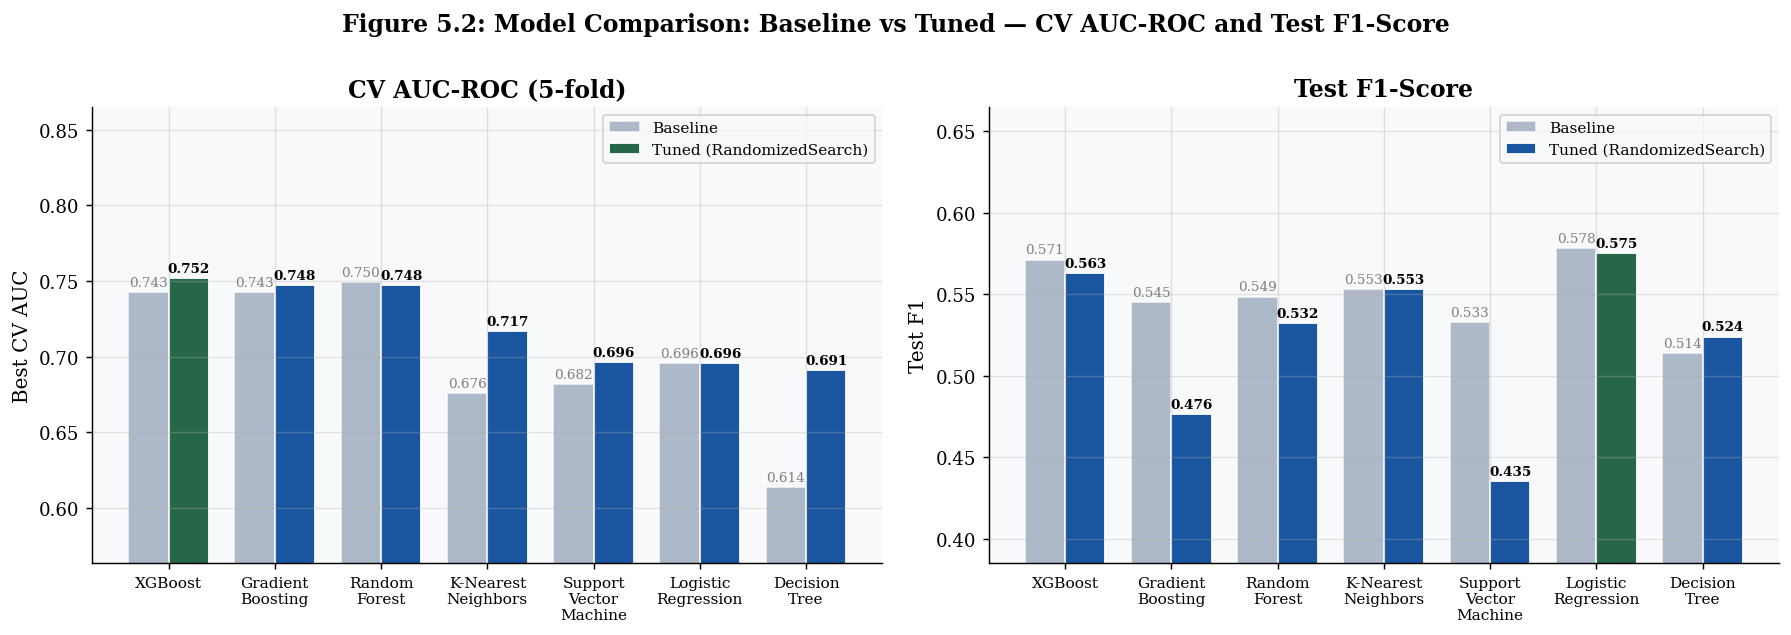

In [29]:
# Comparison bar chart — Tuned vs Baseline
baselines_bl = {
    'Logistic Regression'   : {'Best CV AUC': bl_lr['best_cv_auc'],  'Test F1': bl_lr['f1']},
    'K-Nearest Neighbors'   : {'Best CV AUC': bl_knn['best_cv_auc'], 'Test F1': bl_knn['f1']},
    'Support Vector Machine': {'Best CV AUC': bl_svm['best_cv_auc'], 'Test F1': bl_svm['f1']},
    'Decision Tree'         : {'Best CV AUC': bl_dt['best_cv_auc'],  'Test F1': bl_dt['f1']},
    'Random Forest'         : {'Best CV AUC': bl_rf['best_cv_auc'],  'Test F1': bl_rf['f1']},
    'XGBoost'               : {'Best CV AUC': bl_xgb['best_cv_auc'], 'Test F1': bl_xgb['f1']},
    'Gradient Boosting'     : {'Best CV AUC': bl_gb['best_cv_auc'],  'Test F1': bl_gb['f1']},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names_short = [n.replace(' ', '\n') for n in df_compare.index]
x = np.arange(len(df_compare))
width = 0.38

for ax, (metric, title, ylabel) in zip(axes, [
    ('Best CV AUC', 'CV AUC-ROC (5-fold)', 'Best CV AUC'),
    ('Test F1',     'Test F1-Score',        'Test F1'),
]):
    tuned_vals    = df_compare[metric].values
    baseline_vals = np.array([baselines_bl[n][metric] for n in df_compare.index])

    bars_bl = ax.bar(x - width/2, baseline_vals, width, color=C['gray'],
                     edgecolor='white', label='Baseline', alpha=0.75)
    bars_tuned = ax.bar(x + width/2, tuned_vals, width,
                        color=[C['green'] if v == tuned_vals.max() else C['blue'] for v in tuned_vals],
                        edgecolor='white', label='Tuned (RandomizedSearch)')

    # Value labels
    for bar, v in zip(bars_bl, baseline_vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, color='gray')
    for bar, v in zip(bars_tuned, tuned_vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names_short, fontsize=8.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ymin = max(0, min(baseline_vals.min(), tuned_vals.min()) - 0.05)
    ymax = max(baseline_vals.max(), tuned_vals.max()) * 1.15
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=8.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Figure 5.2: Model Comparison: Baseline vs Tuned — CV AUC-ROC and Test F1-Score',
             fontsize=13, fontweight='bold')
plt.tight_layout(pad=1.5)
plt.savefig('fig_5.2_model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

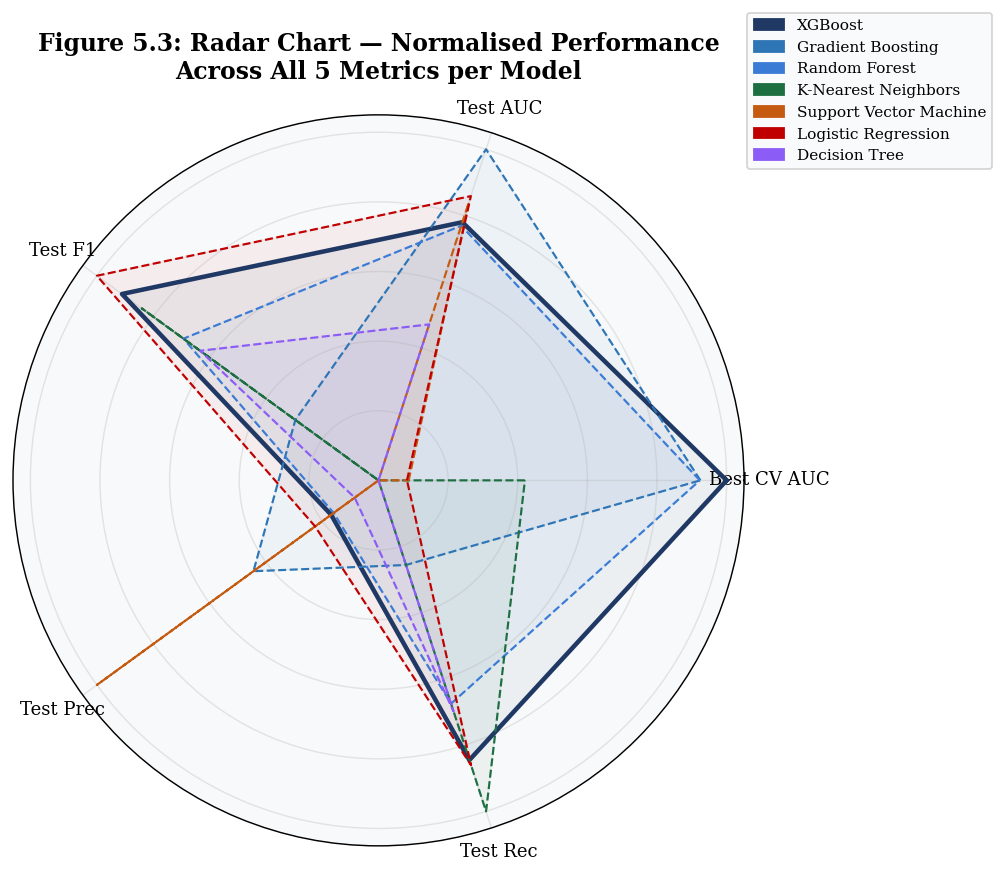

Radar chart interpretation:
- Larger polygon area = stronger overall performance across all 5 metrics.
- Best model outline (solid line) is highlighted for quick identification.
- Metrics are normalised per-column so all axes are on the same scale.


In [30]:
# Radar chart — holistic model comparison
c = {'models':['#1F3864','#2E75B6','#3A7BD5','#1D6F42','#C55A11','#C00000','#8B5CF6']}

radar_metrics = ['Best CV AUC', 'Test AUC', 'Test F1', 'Test Prec', 'Test Rec']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Normalise each metric to [0, 1] across models for fair visual comparison
df_norm = df_compare[radar_metrics].copy()
for col in radar_metrics:
    col_min, col_max = df_norm[col].min(), df_norm[col].max()
    if col_max > col_min:
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)
    else:
        df_norm[col] = 0.5

legend_handles = []
for (name, r), color in zip(ranked_by_cv, c['models']):
    values = df_norm.loc[name, radar_metrics].tolist()
    values += values[:1]
    lw  = 2.5 if name == best_model_name else 1.2
    ls  = '-' if name == best_model_name else '--'
    ax.plot(angles, values, color=color, lw=lw, ls=ls)
    ax.fill(angles, values, color=color, alpha=0.05)
    legend_handles.append(mpatches.Patch(color=color, label=name))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, size=10)
ax.set_yticklabels([])
ax.set_title('Figure 5.3: Radar Chart — Normalised Performance\nAcross All 5 Metrics per Model',
             fontweight='bold', pad=20)
ax.legend(handles=legend_handles, loc='upper right',
          bbox_to_anchor=(1.35, 1.15), fontsize=8.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_5.3_radar_chart.png', dpi=110, bbox_inches='tight')
plt.show()
print("Radar chart interpretation:")
print("- Larger polygon area = stronger overall performance across all 5 metrics.")
print("- Best model outline (solid line) is highlighted for quick identification.")
print("- Metrics are normalised per-column so all axes are on the same scale.")

## 5.5. Evaluation Visualisations

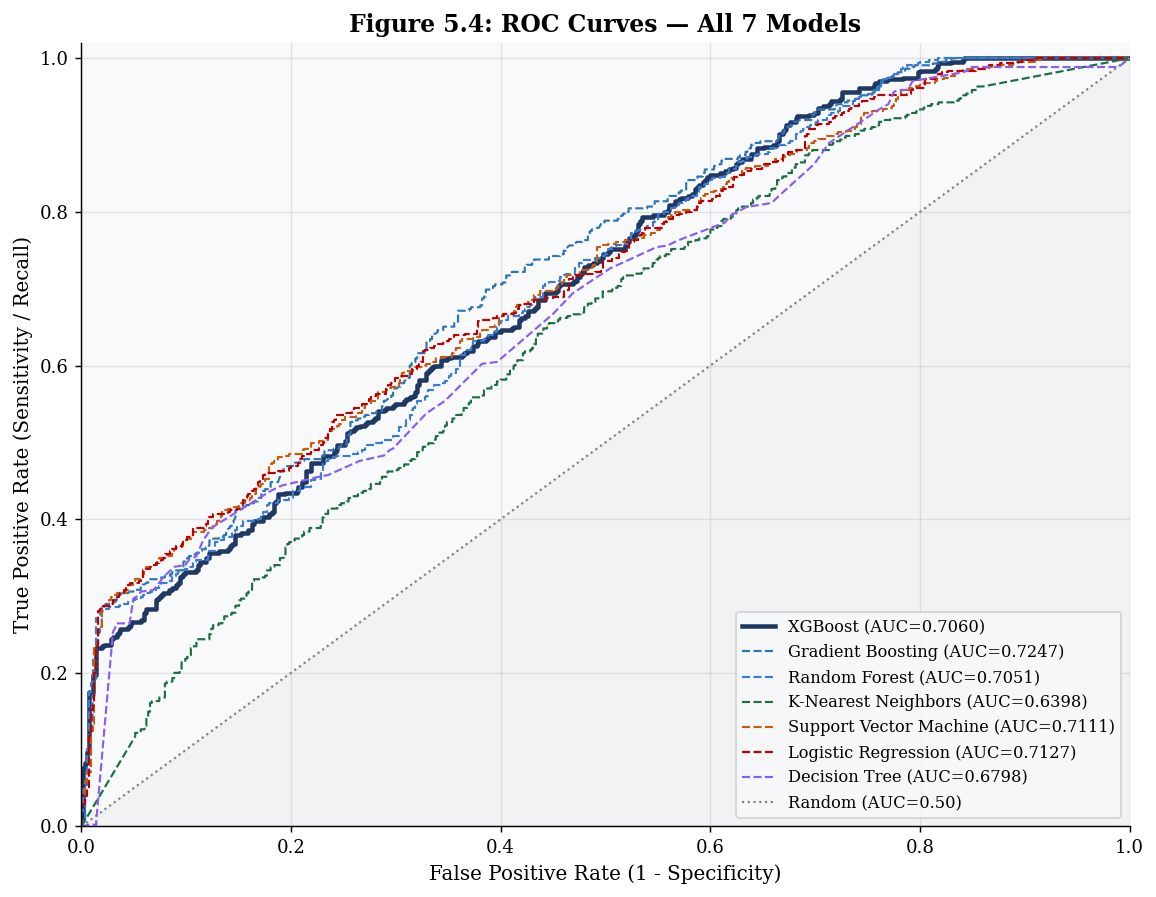

Observation: All ROC curves cluster tightly near the diagonal.
AUC range: 0.6398 – 0.7247 (spread = 0.0848)
This narrow spread confirms that model architecture is not the limiting factor.
The signal ceiling is imposed by the feature set, not the algorithm choice.


In [31]:
# ROC Curves — all models
fig, ax = plt.subplots(figsize=(9, 7))
model_colors = c['models']

for (name, r), color in zip(ranked_by_cv, model_colors):
    lw = 2.5 if name == best_model_name else 1.2
    ls = '-'  if name == best_model_name else '--'
    ax.plot(r['fpr'], r['tpr'], color=color, lw=lw, ls=ls,
            label=f"{name} (AUC={r['auc']:.4f})")

ax.plot([0,1],[0,1], color='grey', lw=1.2, ls=':', label='Random (AUC=0.50)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
ax.set_title('Figure 5.4: ROC Curves — All 7 Models', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_5.4_roc_curves.png', dpi=110, bbox_inches='tight')
plt.show()
print("Observation: All ROC curves cluster tightly near the diagonal.")
print("AUC range: {:.4f} – {:.4f} (spread = {:.4f})".format(
    min(r['auc'] for name, r in ranked_by_cv), max(r['auc'] for name, r in ranked_by_cv),
    max(r['auc'] for name, r in ranked_by_cv) - min(r['auc'] for name, r in ranked_by_cv)))
print("This narrow spread confirms that model architecture is not the limiting factor.")
print("The signal ceiling is imposed by the feature set, not the algorithm choice.")

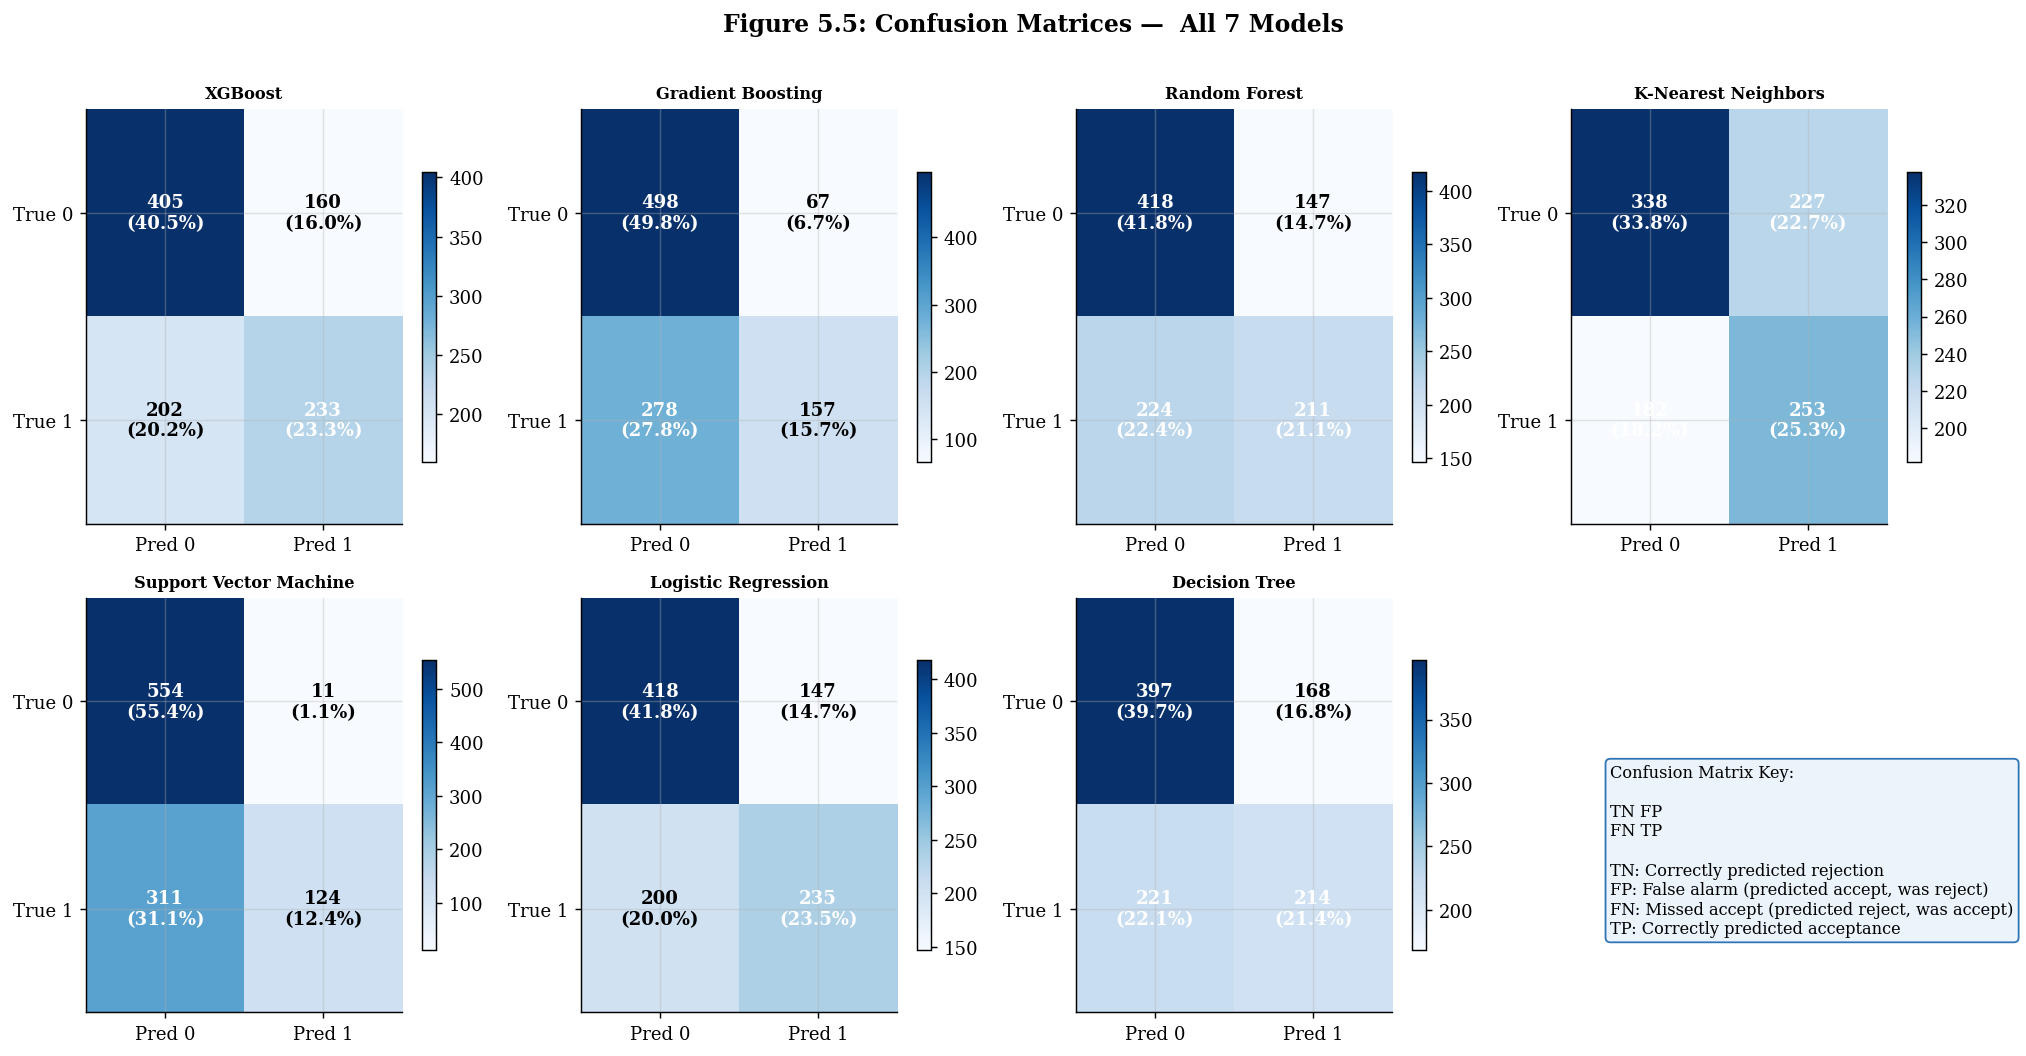

In [32]:
# Confusion matrices — all models
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat  = axes.flatten()

for i, (name, r) in enumerate(ranked_by_cv):
    cm    = r['cm']
    total = cm.sum()
    ax    = axes_flat[i]
    im    = ax.imshow(cm, cmap='Blues', aspect='auto')
    for ri in range(2):
        for ci in range(2):
            ax.text(ci, ri, f'{cm[ri,ci]}\n({cm[ri,ci]/total*100:.1f}%)',
                    ha='center', va='center', fontsize=10,
                    color='white' if cm[ri,ci] > cm.max()/2 else 'black', fontweight='bold')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0','Pred 1']); ax.set_yticklabels(['True 0','True 1'])
    ax.set_title(name, fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7)

axes_flat[-1].axis('off')
axes_flat[-1].text(0.1, 0.6, 'Confusion Matrix Key:\n\nTN FP\nFN TP\n\nTN: Correctly predicted rejection\nFP: False alarm (predicted accept, was reject)\nFN: Missed accept (predicted reject, was accept)\nTP: Correctly predicted acceptance',
    fontsize=9, va='top', transform=axes_flat[-1].transAxes,
    bbox=dict(boxstyle='round', facecolor='#EBF3FB', edgecolor='#2E75B6'))

plt.suptitle('Figure 5.5: Confusion Matrices —  All 7 Models',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_5.5_confusion_matrices.png', dpi=110, bbox_inches='tight')
plt.show()

## 5.6. Feature Importance & Interpretability

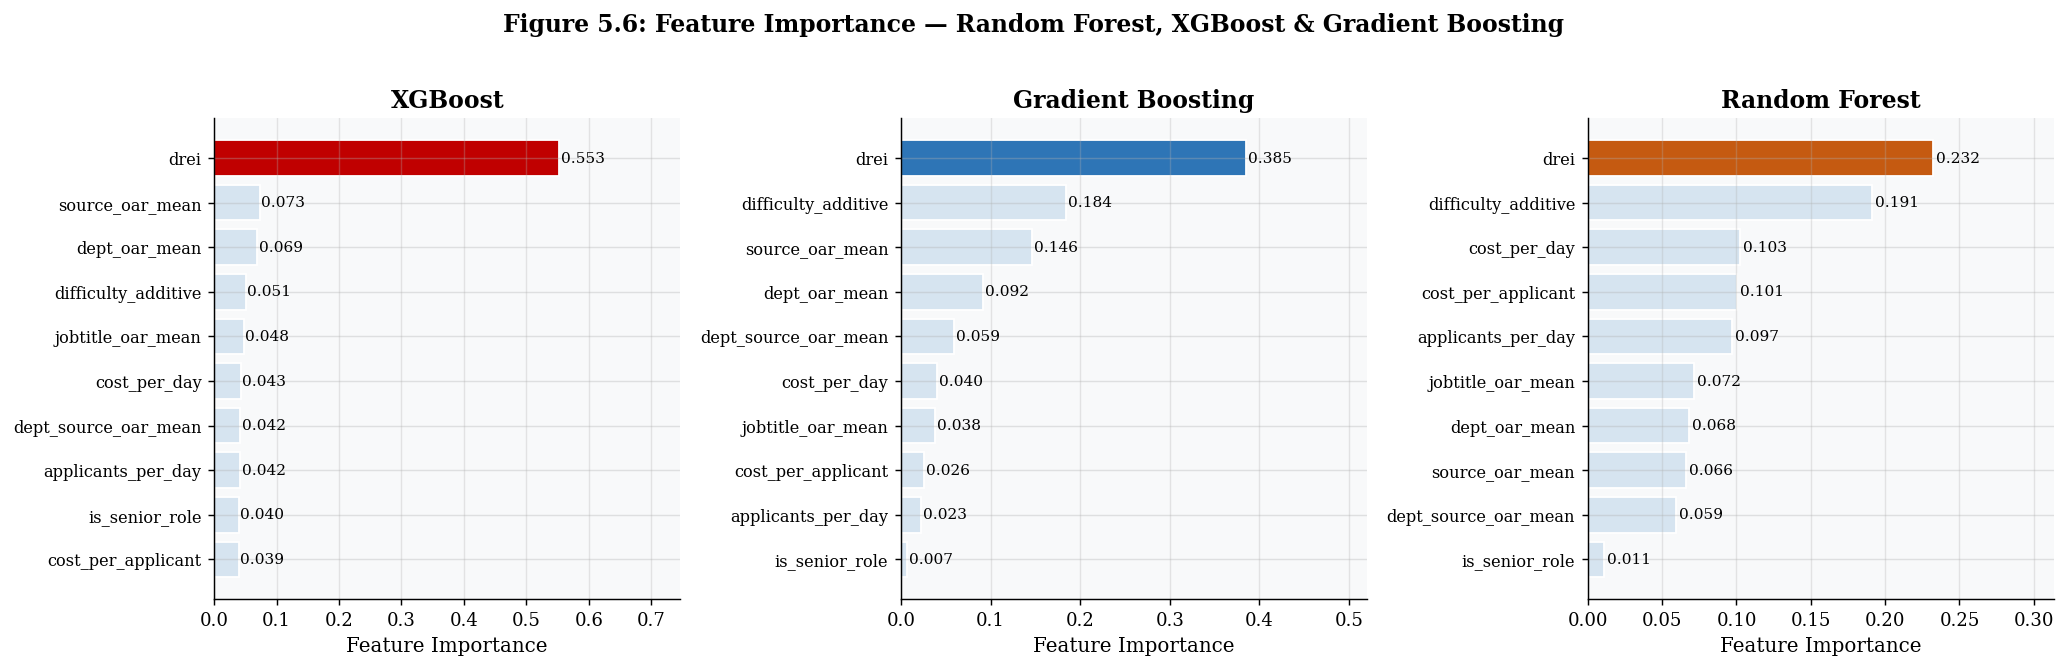

Feature Importance Comparison
                         XGB      GB      RF      Mean
drei                  0.5531  0.3853  0.2323  0.390233
difficulty_additive   0.0507  0.1844  0.1914  0.142167
source_oar_mean       0.0730  0.1462  0.0657  0.094967
dept_oar_mean         0.0694  0.0918  0.0682  0.076467
cost_per_day          0.0434  0.0400  0.1026  0.062000
cost_per_applicant    0.0392  0.0257  0.1006  0.055167
applicants_per_day    0.0419  0.0226  0.0968  0.053767
dept_source_oar_mean  0.0419  0.0593  0.0594  0.053533
jobtitle_oar_mean     0.0476  0.0377  0.0717  0.052333
is_senior_role        0.0398  0.0071  0.0112  0.019367

Key Insights:
Top feature (mean importance): drei
XGB top feature: drei  (0.5531)
GB top feature:  drei  (0.3853)
RF top feature:  drei  (0.2323)


In [33]:
FEAT = list(X_train_raw.columns)

fi_rf  = pd.Series(rf_rs['model'].feature_importances_,  index=FEAT).sort_values(ascending=False)
fi_xgb = pd.Series(xgb_rs['model'].feature_importances_, index=FEAT).sort_values(ascending=False)
fi_gb  = pd.Series(gb_rs['model'].feature_importances_,  index=FEAT).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (fi, model_name, color) in zip(axes, [
    (fi_xgb, 'XGBoost',           '#C00000'),
    (fi_gb,  'Gradient Boosting', '#2E75B6'),
    (fi_rf,  'Random Forest',     '#C55A11'),
]):
    fi_sorted = fi.sort_values()
    bars = ax.barh(range(len(fi_sorted)), fi_sorted.values,
                   color=[color if v == fi_sorted.max() else '#D6E4F0' for v in fi_sorted.values],
                   edgecolor='white')
    ax.set_yticks(range(len(fi_sorted)))
    ax.set_yticklabels(fi_sorted.index, fontsize=9)
    for bar in bars:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.3f}', va='center', fontsize=8.5)
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, fi_sorted.max() * 1.35)

plt.suptitle('Figure 5.6: Feature Importance — Random Forest, XGBoost & Gradient Boosting',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_5.6_feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()

print("Feature Importance Comparison")
fi_df = pd.DataFrame({'XGB': fi_xgb, 'GB': fi_gb, 'RF': fi_rf}).round(4)
fi_df['Mean'] = fi_df.mean(axis=1)
fi_df = fi_df.sort_values('Mean', ascending=False)
print(fi_df.to_string())

print("\nKey Insights:")
top_feat = fi_df.index[0]
print(f"Top feature (mean importance): {top_feat}")
print(f"XGB top feature: {fi_xgb.index[0]}  ({fi_xgb.iloc[0]:.4f})")
print(f"GB top feature:  {fi_gb.index[0]}  ({fi_gb.iloc[0]:.4f})")
print(f"RF top feature:  {fi_rf.index[0]}  ({fi_rf.iloc[0]:.4f})")

## 5.7. Learning Curve

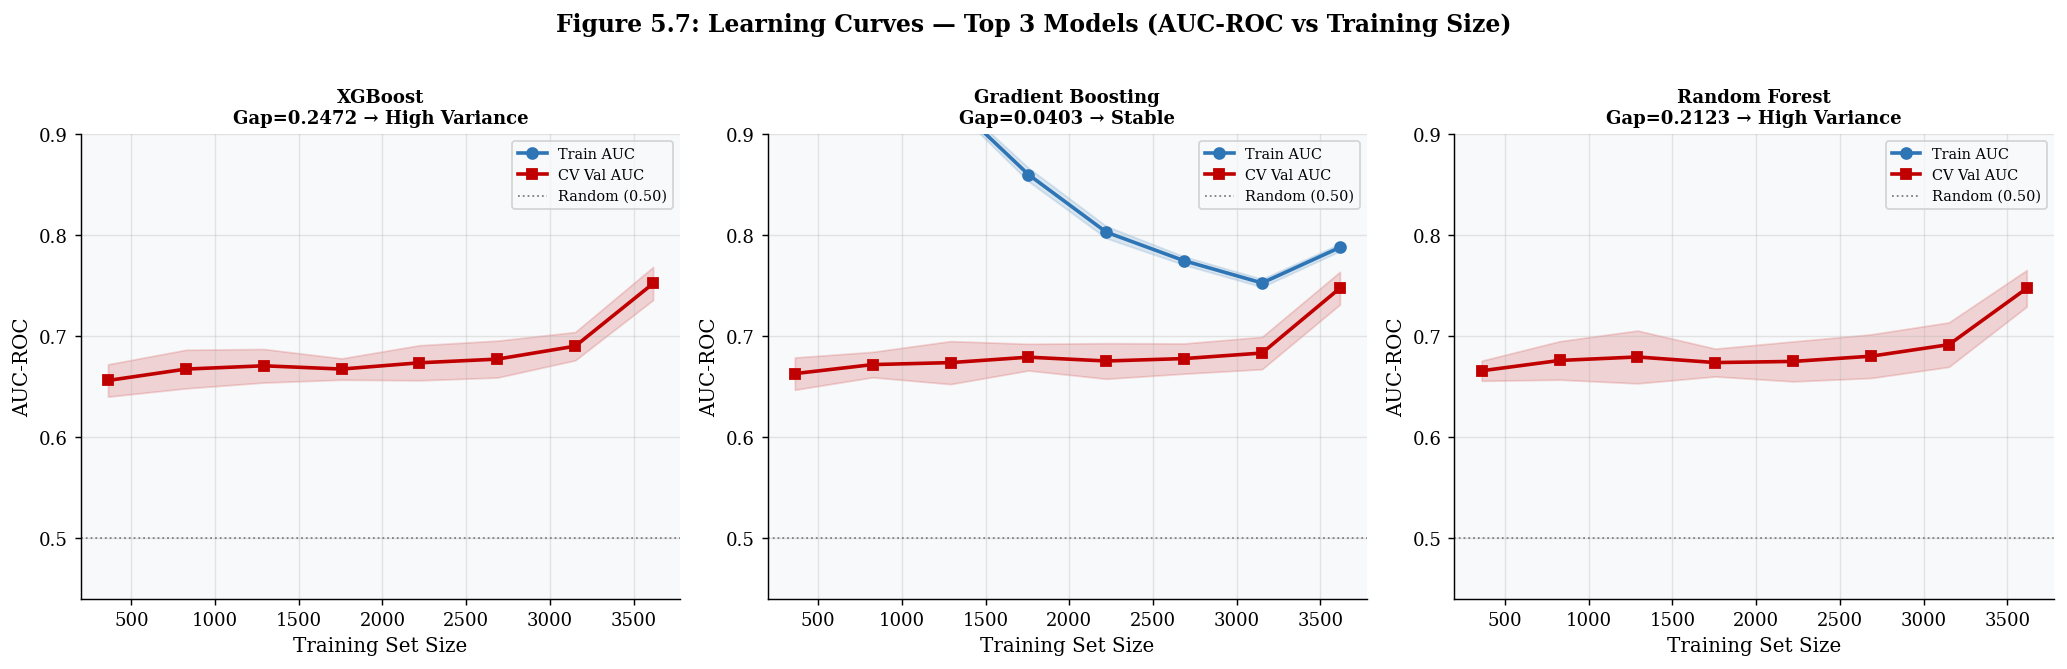

In [34]:
# Learning curves for best 3 models
top3 = [(n, r) for n, r in ranked_by_cv[:3]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (tname, r) in zip(axes, top3):
    Xtr_lc = X_train_smote_std if tname in ['Logistic Regression',
                                              'K-Nearest Neighbors',
                                              'Support Vector Machine'] else X_train_smote_raw
    train_sizes, train_scores, val_scores = learning_curve(
        r['model'], Xtr_lc, y_train_smote,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc', n_jobs=-1,
        train_sizes=np.linspace(0.10, 1.0, 8))

    t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    v_mean, v_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, t_mean, 'o-', color='#2E75B6', lw=2, label='Train AUC')
    ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color='#2E75B6')
    ax.plot(train_sizes, v_mean, 's-', color='#C00000', lw=2, label='CV Val AUC')
    ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='#C00000')
    ax.axhline(0.50, color='grey', lw=1, ls=':', label='Random (0.50)')

    gap       = t_mean[-1] - v_mean[-1]
    diagnosis = 'High Variance' if gap > 0.05 else ('Low Signal' if v_mean[-1] < 0.55 else 'Stable')
    ax.set_title(f'{tname}\nGap={gap:.4f} → {diagnosis}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('AUC-ROC')
    ax.legend(fontsize=8)
    ax.set_ylim(0.44, 0.90)
    ax.grid(alpha=0.3)

plt.suptitle('Figure 5.7: Learning Curves — Top 3 Models (AUC-ROC vs Training Size)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_5.7_learning_curves.png', dpi=110, bbox_inches='tight')
plt.show()

## 5.8. Explainable AI — SHAP

**SHAP (SHapley Additive exPlanations)** decomposes any model prediction into additive contributions from each feature, rooted in cooperative game theory. For each prediction:

$$\hat{f}(x) = \phi_0 + \sum_{i=1}^{M} \phi_i$$

where $\phi_0$ is the base rate (global mean prediction) and $\phi_i$ is the SHAP value (marginal contribution) of feature $i$. SHAP values satisfy three desirable axioms: **Efficiency** (values sum to the prediction gap), **Symmetry** (equal-contribution features receive equal attribution), and **Linearity** (additive models decompose correctly).

For XGBoost, the `TreeExplainer` computes exact SHAP values in polynomial time by traversing the tree ensemble directly.

In [35]:
# ── Load Datasets
train_raw  = pd.read_csv('train_smote_raw.csv')
test_raw   = pd.read_csv('test_raw.csv')
df_orig    = pd.read_csv('recruitment_efficiency_improved.csv')

FEATURE_COLS = [
    'cost_per_applicant', 'cost_per_day', 'applicants_per_day',
    'is_senior_role', 'difficulty_additive', 'drei',
    'dept_oar_mean', 'jobtitle_oar_mean', 'source_oar_mean', 'dept_source_oar_mean'
]
TARGET_COL = 'target_high_oar'

X_train = train_raw[FEATURE_COLS].copy()
y_train = train_raw[TARGET_COL].copy()
X_test  = test_raw[FEATURE_COLS].copy()
y_test  = test_raw[TARGET_COL].copy()

# Replace infinite values
for df in [X_train, X_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# ── Reconstruct Best XGBoost Model
xgb_model = XGBClassifier(
    n_estimators      = 317,
    max_depth         = 8,
    learning_rate     = 0.06420330336297862,
    subsample         = 0.9706635463175177,
    colsample_bytree  = 0.7246844304357644,
    min_child_weight  = 2,
    gamma             = 0.2600340105889054,
    reg_alpha         = 0.006295301484516136,
    reg_lambda        = 0.009456951897345888,
    eval_metric       = 'logloss',
    random_state      = 42,
    use_label_encoder = False,
)

xgb_model.fit(X_train, y_train)

# Evaluate on test set
y_pred      = xgb_model.predict(X_test)
y_prob      = xgb_model.predict_proba(X_test)[:, 1]

print('── XGBoost — Test Set Performance (Stage 2 Reproduction Check)')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Low OAR (0)', 'High OAR (1)']))

── XGBoost — Test Set Performance (Stage 2 Reproduction Check)
  Accuracy  : 0.6380
  Precision : 0.5929
  Recall    : 0.5356
  F1-Score  : 0.5628
  AUC-ROC   : 0.7060

              precision    recall  f1-score   support

 Low OAR (0)       0.67      0.72      0.69       565
High OAR (1)       0.59      0.54      0.56       435

    accuracy                           0.64      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.63      0.64      0.64      1000



In [ ]:
import shap
import lime
import lime.lime_tabular

# ── SHAP TreeExplainer ────────────────────────────────────────────────────────
explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test)
expected_val = explainer.expected_value

print(f'SHAP base value (expected model output): {expected_val:.4f}')
print(f'SHAP values shape                      : {shap_values.shape}')
print(f'Mean |SHAP| per feature (global importance):')
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)
print(mean_shap.to_string())

### 5.8.1. SHAP Summary Plot (Beeswarm)

The beeswarm plot shows, for every test observation, how much each feature pushed the model's prediction above or below the base rate. Points are coloured by the raw feature value (red = high, blue = low), enabling simultaneous interpretation of direction and magnitude.

In [ ]:
# ── SHAP Beeswarm Summary Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=None,
    max_display=10,
    color_bar_label='Feature Value'
)
plt.title('Figure 5.8: SHAP Summary Plot — XGBoost (Test Set, n=1,000)',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_5.8_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key observations:')
print('- drei (Difficulty-Recruitment Efficiency Index) is the dominant feature')
print('- Higher drei values strongly push predictions toward High OAR (positive SHAP)')
print('- jobtitle_oar_mean and dept_source_oar_mean show moderate directional effects')
print('- is_senior_role consistently reduces acceptance probability (negative SHAP)')

In [ ]:
import matplotlib.gridspec as gridspec

# Split by actual OAR label (or use predicted probability threshold)
mask_low  = y_test == 0
mask_high = y_test == 1

shap_low  = shap_values[mask_low]
shap_high = shap_values[mask_high]
X_low     = X_test[mask_low]
X_high    = X_test[mask_high]

fig = plt.figure(figsize=(20, 7))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Left panel: Low OAR
ax1 = fig.add_subplot(gs[0])
shap.summary_plot(shap_low, X_low,
    feature_names=FEATURE_COLS,
    show=False, plot_size=None,
    max_display=10,
    color_bar_label='Feature Value')
ax1.set_title('Low OAR (n={})'.format(mask_low.sum()),
              fontsize=12, fontweight='bold')
ax1.set_xlim(-4, 4)   # symmetric axis for fair comparison

# ── Right panel: High OAR
ax2 = fig.add_subplot(gs[1])
shap.summary_plot(shap_high, X_high,
    feature_names=FEATURE_COLS,
    show=False, plot_size=None,
    max_display=10,
    color_bar_label='Feature Value')
ax2.set_title('High OAR (n={})'.format(mask_high.sum()),
              fontsize=12, fontweight='bold')
ax2.set_xlim(-4, 4)

fig.suptitle(
    'Figure 5.8: SHAP Local Focus — Low OAR vs High OAR',
    fontsize=14, fontweight='bold', y=1.02)

# plt.savefig('fig_5.8_shap_local_split.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.8.2. SHAP Bar Plot (Global Feature Importance)

In [ ]:
# ── SHAP Mean |SHAP| Bar Plot
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS
).sort_values()

# Colour scale: top 3 features highlighted
colors = [C['blue'] if i >= len(mean_abs_shap) - 2 else C['gray']
          for i in range(len(mean_abs_shap))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=colors, alpha=0.85, height=0.6)

for bar, val in zip(bars, mean_abs_shap.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Mean |SHAP Value|  (average impact on model output magnitude)', fontsize=10)
ax.set_title('Figure 5.9: Global Feature Importance — Mean |SHAP|\n'
             'XGBoost — Test Set (n=1,000)', fontsize=12, fontweight='bold')
ax.set_xlim(0, mean_abs_shap.max() * 1.20)

highlighted = mpatches.Patch(color=C['blue'], label='Top-2 features')
other       = mpatches.Patch(color=C['gray'], label='Other features')
ax.legend(handles=[highlighted, other], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('fig_5.9_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Split indices by actual OAR label (or use predicted probability)
mask_low  = (y_test == 0)
mask_high = (y_test == 1)

def mean_abs_shap_series(shap_vals, mask):
    return (
        pd.Series(np.abs(shap_vals[mask]).mean(axis=0), index=FEATURE_COLS)
        .sort_values()          # ascending so largest bar is at top
    )

low_shap  = mean_abs_shap_series(shap_values, mask_low)
high_shap = mean_abs_shap_series(shap_values, mask_high)

# ── Shared x-axis limit for fair comparison
x_max = max(low_shap.max(), high_shap.max()) * 1.20

# ── Color helpers: highlight top-2 per panel independently
def bar_colors(series, top_n=2, hi_col='#185FA5', lo_col='#9E9E9E'):
    n = len(series)
    return [hi_col if i >= n - top_n else lo_col for i in range(n)]

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.40)

for ax, series, group, top_col in [
    (fig.add_subplot(gs[0]), low_shap,  'Low OAR',  '#2166AC'),
    (fig.add_subplot(gs[1]), high_shap, 'High OAR', '#B2182B'),
]:
    colors = bar_colors(series, top_n=2, hi_col=top_col)
    bars = ax.barh(series.index, series.values,
                   color=colors, alpha=0.85, height=0.6)

    for bar, val in zip(bars, series.values):
        ax.text(val + x_max * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlim(0, x_max)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
    ax.set_title(
        f'Local Feature Importance — {group}\n(n={mask_low.sum() if "Low" in group else mask_high.sum()})',
        fontsize=11, fontweight='bold'
    )
    top_patch  = mpatches.Patch(color=top_col,  label='Top-2 features')
    other_patch = mpatches.Patch(color='#9E9E9E', label='Other features')
    ax.legend(handles=[top_patch, other_patch], fontsize=9, loc='lower right')

fig.suptitle(
    'Figure 5.9: Local Feature Importance — Mean |SHAP| by OAR Group\n'
    'XGBoost — Test Set',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
# plt.savefig('fig_5.9_shap_bar_local.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.8.3. SHAP Dependence Plots

Dependence plots reveal how the SHAP value of a feature changes across its value range, with interaction colouring from the most co-varying feature.

In [ ]:
# ── SHAP Dependence Plots (Top Feature)
top3_features = mean_abs_shap.sort_values(ascending=False).index[:3].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Figure 5.10: SHAP Dependence Plots — Top 2 Features',
             fontsize=13, fontweight='bold', y=1.02)

for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(
        feat, shap_values, X_test,
        feature_names=FEATURE_COLS,
        ax=ax, show=False
    )
    ax.set_title(f'{feat}', fontsize=10, fontweight='bold')
    ax.axhline(0, color='grey', lw=1, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_5.10_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 1. Split masks
mask_low  = (y_test == 0)
mask_high = (y_test == 1)

shap_low,  X_low  = shap_values[mask_low],  X_test[mask_low]
shap_high, X_high = shap_values[mask_high], X_test[mask_high]

# ── 2. Features to plot (top-2 from global importance)
top2 = mean_abs_shap.sort_values(ascending=False).index[:2].tolist()
# e.g. ['drei', 'difficulty_additive']

# ── 3. Build 2-row × 2-col grid
#       rows = features,  cols = [Low OAR, High OAR]
n_feat = len(top2)
fig = plt.figure(figsize=(14, 4 * n_feat))
gs  = gridspec.GridSpec(n_feat, 2, figure=fig,
                        hspace=0.45, wspace=0.35)

groups = [
    ('Low OAR',  shap_low,  X_low,  mask_low.sum(),  '#2166AC'),
    ('High OAR', shap_high, X_high, mask_high.sum(), '#B2182B'),
]

for row, feat in enumerate(top2):
    for col, (label, sv, Xg, n, title_col) in enumerate(groups):
        ax = fig.add_subplot(gs[row, col])

        shap.dependence_plot(
            feat, sv, Xg,
            feature_names=FEATURE_COLS,
            ax=ax, show=False
        )
        ax.axhline(0, color='grey', lw=1, ls='--', alpha=0.5)
        ax.set_title(
            f'{feat}  ·  {label}  (n={n})',
            fontsize=10, fontweight='bold', color=title_col
        )

        # ── Optional: fix y-axis range to the global extent
        #    so Low/High panels are directly comparable
        global_sv = shap_values[:, FEATURE_COLS.index(feat)]
        y_pad = (global_sv.max() - global_sv.min()) * 0.05
        ax.set_ylim(global_sv.min() - y_pad, global_sv.max() + y_pad)

fig.suptitle(
    'Figure 5.10: SHAP Dependence Plots — Local (Low OAR vs High OAR)\n'
    'Top-2 Features · XGBoost · Test Set',
    fontsize=13, fontweight='bold', y=1.01
)
# plt.savefig('fig_5.10_shap_dependence_local.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.8.4. SHAP Force Plot — Individual Predictions

Force plots explain single predictions by showing how each feature pushes the model output from the base value toward the final prediction. Red arrows push toward High OAR; blue arrows push toward Low OAR.

In [ ]:
# ── SHAP Force Plot: High OAR Prediction
# Select a clear High-OAR predicted case
high_oar_idx = np.where((y_pred == 1) & (y_prob > 0.75))[0]
idx_high = high_oar_idx[0] if len(high_oar_idx) > 0 else 0

print('── Force Plot: High OAR Prediction (probability > 0.75)')
print(f'   Sample index   : {idx_high}')
print(f'   Predicted class: High OAR (1)')
print(f'   Predicted prob : {y_prob[idx_high]:.4f}')
print(f'   Actual label   : {y_test.iloc[idx_high]}')
print('\n   Feature values:')
for feat, val in X_test.iloc[idx_high].items():
    shap_val = shap_values[idx_high, FEATURE_COLS.index(feat)]
    direction = '+' if shap_val > 0 else '-'
    print(f'   {feat:<28} = {val:>10.4f}   SHAP: {direction}{abs(shap_val):.4f}')

shap.initjs()
force_plot_high = shap.force_plot(
    expected_val,
    shap_values[idx_high],
    X_test.iloc[idx_high],
    feature_names=FEATURE_COLS,
    matplotlib=False
)
display(force_plot_high)

In [ ]:
# ── SHAP Force Plot: Low OAR Prediction
low_oar_idx = np.where((y_pred == 0) & (y_prob < 0.25))[0]
idx_low = low_oar_idx[0] if len(low_oar_idx) > 0 else 1

print('── Force Plot: Low OAR Prediction (probability < 0.25)')
print(f'   Sample index   : {idx_low}')
print(f'   Predicted class: Low OAR (0)')
print(f'   Predicted prob : {y_prob[idx_low]:.4f}')
print(f'   Actual label   : {y_test.iloc[idx_low]}')
print('\n   Feature values:')
for feat, val in X_test.iloc[idx_low].items():
    shap_val = shap_values[idx_low, FEATURE_COLS.index(feat)]
    direction = '+' if shap_val > 0 else '-'
    print(f'   {feat:<28} = {val:>10.4f}   SHAP: {direction}{abs(shap_val):.4f}')

force_plot_low = shap.force_plot(
    expected_val,
    shap_values[idx_low],
    X_test.iloc[idx_low],
    feature_names=FEATURE_COLS,
    matplotlib=False
)
display(force_plot_low)

In [ ]:
# ── Waterfall Plot: Single Prediction Breakdown
# SHAP Explanation object for newer API
explanation = shap.Explanation(
    values      = shap_values[idx_high],
    base_values = expected_val,
    data        = X_test.iloc[idx_high].values,
    feature_names = FEATURE_COLS
)

fig, ax = plt.subplots(figsize=(9, 5))
shap.plots.waterfall(explanation, show=False, max_display=10)
plt.title('Figure 5.11: SHAP Waterfall — High OAR Prediction Breakdown',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_5.11_shap_waterfall_high.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Waterfall Plot: Single Prediction Breakdown (Low OAR)
explanation = shap.Explanation(
    values        = shap_values[idx_low],
    base_values   = expected_val,
    data          = X_test.iloc[idx_low].values,
    feature_names = FEATURE_COLS
)

fig, ax = plt.subplots(figsize=(9, 5))
shap.plots.waterfall(explanation, show=False, max_display=10)
plt.title('Figure 5.11: SHAP Waterfall — Low OAR Prediction Breakdown',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_5.11_shap_waterfall_low.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.9. Explainable AI — LIME

**LIME (Local Interpretable Model-agnostic Explanations)** approximates the complex model locally around any individual prediction by fitting a simple linear model to perturbed versions of the input. It answers the question: *"For this specific prediction, which features mattered most, and in which direction?"*

LIME complements SHAP by providing an independent, model-agnostic cross-check of local feature attributions.

In [ ]:
# ── LIME Explainer Setup
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_train.values,
    feature_names         = FEATURE_COLS,
    class_names           = ['Low OAR (0)', 'High OAR (1)'],
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

# ── LIME Explanation — High OAR Case
lime_exp_high = lime_explainer.explain_instance(
    data_row     = X_test.iloc[idx_high].values,
    predict_fn   = xgb_model.predict_proba,
    num_features = 10,
    num_samples  = 5000,
    top_labels   = 2
)
print('── LIME Explanation: High OAR Prediction')
print(f'   LIME local prediction probability (High OAR): {lime_exp_high.local_pred[0]:.4f}')
print(f'   XGBoost actual probability                  : {y_prob[idx_high]:.4f}')
print('\n   Feature contributions:')
for feat, weight in lime_exp_high.as_list(label=1):
    direction = '▲ pushes toward High OAR' if weight > 0 else '▼ pushes toward Low OAR'
    print(f'   {feat:<40} weight={weight:>+.4f}  {direction}')
fig = lime_exp_high.as_pyplot_figure(label=1)
fig.set_size_inches(9, 5)
fig.suptitle('Figure 5.12: LIME Explanation — High OAR Prediction',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_5.12_lime_high.png', dpi=150, bbox_inches='tight')
plt.show()

# ── LIME Explanation — Low OAR Case
lime_exp_low = lime_explainer.explain_instance(
    data_row     = X_test.iloc[idx_low].values,
    predict_fn   = xgb_model.predict_proba,
    num_features = 10,
    num_samples  = 5000,
    top_labels   = 2
)
print('── LIME Explanation: Low OAR Prediction')
print(f'   LIME local prediction probability (Low OAR) : {lime_exp_low.local_pred[0]:.4f}')
print(f'   XGBoost actual probability                  : {y_prob[idx_low]:.4f}')
print('\n   Feature contributions (relative to label=0):')
for feat, weight in lime_exp_low.as_list(label=0):
    # weight > 0 means this feature supports label=0 (Low OAR)
    direction = '▼ pushes toward Low OAR' if weight > 0 else '▲ pushes toward High OAR'
    print(f'   {feat:<40} weight={weight:>+.4f}  {direction}')
fig = lime_exp_low.as_pyplot_figure(label=0)
fig.set_size_inches(9, 5)
fig.suptitle('Figure 5.13: LIME Explanation — Low OAR Prediction',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_5.13_lime_low.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── LIME Explainer Setup
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = FEATURE_COLS,
    class_names    = ['Low OAR (0)', 'High OAR (1)'],
    mode           = 'classification',
    discretize_continuous = True,
    random_state   = 42
)

In [ ]:
# ── LIME Explanation — High OAR Case
lime_exp_high = lime_explainer.explain_instance(
    data_row     = X_test.iloc[idx_high].values,
    predict_fn   = xgb_model.predict_proba,
    num_features = 10,
    num_samples  = 5000,
    top_labels   = 2
)

print('── LIME Explanation: High OAR Prediction')
print(f'   LIME local prediction probability (High OAR): {lime_exp_high.local_pred[0]:.4f}')  # [0] not [1]
print(f'   XGBoost actual probability                  : {y_prob[idx_high]:.4f}')
print('\n   Feature contributions:')
for feat, weight in lime_exp_high.as_list(label=1):
    direction = '▲ pushes toward High OAR' if weight > 0 else '▼ pushes toward Low OAR'
    print(f'   {feat:<40} weight={weight:>+.4f}  {direction}')

fig = lime_exp_high.as_pyplot_figure(label=1)
fig.set_size_inches(9, 5)
fig.suptitle('Figure 5.12: LIME Explanation — High OAR Prediction',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_5.12_lime_high.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── LIME Explanation — Low OAR Case
lime_exp_low = lime_explainer.explain_instance(
    data_row     = X_test.iloc[idx_low].values,
    predict_fn   = xgb_model.predict_proba,
    num_features = 10,
    num_samples  = 5000,
    top_labels   = 2
)

print('── LIME Explanation: Low OAR Prediction')
print(f'   LIME local prediction probability (Low OAR) : {lime_exp_low.local_pred[0]:.4f}')
print(f'   XGBoost actual probability                  : {y_prob[idx_low]:.4f}')
print('\n   Feature contributions:')
for feat, weight in lime_exp_low.as_list(label=0):
    direction = '▼ pushes toward Low OAR' if weight > 0 else '▲ pushes toward High OAR'
    print(f'   {feat:<40} weight={weight:>+.4f}  {direction}')

fig = lime_exp_low.as_pyplot_figure(label=0)
fig.set_size_inches(9, 5)
fig.suptitle('Figure 5.13: LIME Explanation — Low OAR Prediction',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_5.13_lime_low.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── LIME vs SHAP Local Agreement
# Compare LIME and SHAP attributions for the same high-OAR case
shap_local = pd.Series(shap_values[idx_high], index=FEATURE_COLS)

lime_dict = dict([(k.split('=')[0].split('>')[0].split('<')[0].strip(),  v)
                   for k, v in lime_exp_high.as_list(label=1)])

# Match features by partial string (LIME uses binned feature names)
lime_mapped = {}
for feat in FEATURE_COLS:
    for lime_key in lime_dict:
        if feat in lime_key or lime_key in feat:
            lime_mapped[feat] = lime_dict[lime_key]
            break
    if feat not in lime_mapped:
        lime_mapped[feat] = 0.0

lime_series = pd.Series(lime_mapped)[FEATURE_COLS]

print('── SHAP vs LIME Agreement (High OAR sample)')
print(f"{'Feature':<28} {'SHAP':>8} {'LIME':>8} {'Same Direction':>15}")
print('─' * 65)
for feat in FEATURE_COLS:
    s = shap_local[feat]
    l = lime_series[feat]
    agree = '✓' if (s * l >= 0) else '✗'
    print(f'  {feat:<26} {s:>+8.4f} {l:>+8.4f} {agree:>15}')

## 5.10. Bias & Fairness Assessment

Fairness in recruitment analytics is critical. Even a model that achieves acceptable aggregate accuracy may behave inequitably across subgroups — systematically under-predicting acceptance for certain departments or recruitment channels. This section analyses:

1. **Prediction rate disparities** across Department, Recruitment Source, and Job Title  
2. **Performance metric disparities** (accuracy, precision, recall) by subgroup  
3. **Error pattern analysis** to identify where the model consistently mispredicts

In [ ]:
# ── Reconstruct Test Set with Categorical Labels
df_feat = df_orig.copy()
df_feat['target_high_oar'] = (df_feat['offer_acceptance_rate'] >= 0.70).astype(int)

# Reconstruct ONLY the simple engineered features (no target encoding)
df_feat['cost_per_applicant'] = df_feat['cost_per_hire'] / df_feat['num_applicants']
df_feat['cost_per_day']       = df_feat['cost_per_hire'] / df_feat['time_to_hire_days']
df_feat['applicants_per_day'] = df_feat['num_applicants'] / df_feat['time_to_hire_days']
df_feat['is_senior_role']     = (
    df_feat['job_title']
    .str.contains(r'\b(manager|specialist|executive|strategist)\b', case=False, na=False)
    .astype(int)
)

# ── Only select columns that actually exist in df_feat
CATEGORICAL_COLS = ['department', 'source', 'job_title']
available_feat_cols = [c for c in FEATURE_COLS if c in df_feat.columns]
select_cols = available_feat_cols + CATEGORICAL_COLS

print('FEATURE_COLS missing from df_feat:')
print([c for c in FEATURE_COLS if c not in df_feat.columns])
print(f'\nUsing {len(available_feat_cols)}/{len(FEATURE_COLS)} feature cols + categoricals')

X_raw_all = df_feat[select_cols].copy()
y_all     = df_feat['target_high_oar'].copy()

# Rebuild train/test split with same seed to recover test index
_, X_te_full, _, y_te_full = train_test_split(
    X_raw_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# ── Build fairness df using ONLY the categorical columns for subgroup analysis
df_fairness = X_te_full[CATEGORICAL_COLS].copy()
df_fairness['y_true']  = y_te_full.values
df_fairness['y_pred']  = y_pred
df_fairness['y_prob']  = y_prob
df_fairness['correct'] = (df_fairness['y_true'] == df_fairness['y_pred']).astype(int)
df_fairness['FP']      = ((df_fairness['y_pred'] == 1) & (df_fairness['y_true'] == 0)).astype(int)
df_fairness['FN']      = ((df_fairness['y_pred'] == 0) & (df_fairness['y_true'] == 1)).astype(int)

print(f'\nFairness evaluation set: {len(df_fairness):,} rows')
print('Subgroup columns:', CATEGORICAL_COLS)

In [ ]:
def subgroup_metrics(df, group_col):
    """Compute accuracy, precision, recall, F1, AUC-ROC, predicted positive rate per group."""
    rows = []
    for grp, sub in df.groupby(group_col):
        yt, yp, ypr = sub['y_true'], sub['y_pred'], sub['y_prob']
        
        # AUC-ROC requires at least one sample of each class
        try:
            auc = round(roc_auc_score(yt, ypr), 3)
        except ValueError:
            auc = float('nan')  # subgroup has only one class
        
        rows.append({
            'Group'      : grp,
            'N'          : len(sub),
            'True +Rate' : round(yt.mean(), 3),
            'Pred +Rate' : round(yp.mean(), 3),
            'Accuracy'   : round(accuracy_score(yt, yp), 3),
            'Precision'  : round(precision_score(yt, yp, zero_division=0), 3),
            'Recall'     : round(recall_score(yt, yp, zero_division=0), 3),
            'F1'         : round(f1_score(yt, yp, zero_division=0), 3),
            'AUC-ROC'    : auc,
            'FP Rate'    : round(sub['FP'].mean(), 3),
            'FN Rate'    : round(sub['FN'].mean(), 3),
        })
    return pd.DataFrame(rows).set_index('Group').sort_values('F1', ascending=False)

dept_metrics   = subgroup_metrics(df_fairness, 'department')
source_metrics = subgroup_metrics(df_fairness, 'source')
title_metrics  = subgroup_metrics(df_fairness, 'job_title')

print('── Subgroup Metrics by Recruitment Source')
print(source_metrics.to_string())
print('\n── Subgroup Metrics by Department')
print(dept_metrics.to_string())
print('\n── Subgroup Metrics by Job Title')
print(title_metrics.to_string())

In [ ]:
# ── Re-run with AUC-ROC included
from sklearn.metrics import roc_auc_score

def subgroup_metrics(df, group_col):
    """Compute accuracy, precision, recall, F1, AUC-ROC, predicted positive rate per group."""
    rows = []
    for grp, sub in df.groupby(group_col):
        yt, yp, ypr = sub['y_true'], sub['y_pred'], sub['y_prob']
        try:
            auc = round(roc_auc_score(yt, ypr), 3)
        except ValueError:
            auc = float('nan')
        rows.append({
            'Group'      : grp,
            'N'          : len(sub),
            'True +Rate' : round(yt.mean(), 3),
            'Pred +Rate' : round(yp.mean(), 3),
            'Accuracy'   : round(accuracy_score(yt, yp), 3),
            'Precision'  : round(precision_score(yt, yp, zero_division=0), 3),
            'Recall'     : round(recall_score(yt, yp, zero_division=0), 3),
            'F1'         : round(f1_score(yt, yp, zero_division=0), 3),
            'AUC-ROC'    : auc,
            'FP Rate'    : round(sub['FP'].mean(), 3),
            'FN Rate'    : round(sub['FN'].mean(), 3),
        })
    return pd.DataFrame(rows).set_index('Group').sort_values('F1', ascending=False)

# Regenerate all three
dept_metrics   = subgroup_metrics(df_fairness, 'department')
source_metrics = subgroup_metrics(df_fairness, 'source')
title_metrics  = subgroup_metrics(df_fairness, 'job_title')

print(dept_metrics[['F1', 'AUC-ROC']].to_string())

In [ ]:
# ── Model Performance by Source and Department (AUC-ROC & F1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 5.14: Model Performance by Subgroup — AUC-ROC & F1-Score',
             fontsize=13, fontweight='bold')

w = 0.35

for ax, (metrics_df, group_name) in zip(axes, [
    (source_metrics, 'Recruitment Source'),
    (dept_metrics,   'Department'),
]):
    plot_df = metrics_df[['F1', 'AUC-ROC']].copy()
    x = np.arange(len(plot_df))

    bars_f1  = ax.bar(x - w/2, plot_df['F1'],      width=w, label='F1-Score', color=C['blue'], alpha=0.85)
    bars_auc = ax.bar(x + w/2, plot_df['AUC-ROC'], width=w, label='AUC-ROC',  color=C['teal'], alpha=0.85)

    # ── Bar labels
    for bar in bars_f1:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
    for bar in bars_auc:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

    # ── Mean lines
    ax.axhline(plot_df['F1'].mean(),      color=C['blue'], lw=1.5, ls='--', alpha=0.6, label='Mean F1')
    ax.axhline(plot_df['AUC-ROC'].mean(), color=C['teal'], lw=1.5, ls='--', alpha=0.6, label='Mean AUC-ROC')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=0, ha='center', fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score')
    ax.set_title(f'F1 vs AUC-ROC by {group_name}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_5.14_source_dept_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Heatmap by Job Title (AUC-ROC & F1)
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(title_metrics) * 0.4)))
fig.suptitle('Figure 5.15: Model Performance by Job Title — AUC-ROC & F1-Score',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['F1', 'AUC-ROC']):
    data = title_metrics[[metric]].copy().sort_values(metric, ascending=False)
    im = ax.imshow(data.values, aspect='auto', cmap='RdYlGn',
                   vmin=0, vmax=1)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=8)
    ax.set_xticks([])
    ax.set_title(f'{metric} by Job Title')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

    # Annotate each cell with value
    for i, val in enumerate(data.values.flatten()):
        color = 'black' if 0.3 < val < 0.8 else 'white'
        ax.text(0, i, f'{val:.3f}', ha='center', va='center',
                fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_5.15_jobtitle_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()